# <h1><center id="uplift-top">Модели индивидуального эффекта коммуникации</center></h1>

### Оглавление
* <a href="#uplift-imports">0. Импорты и воспроизводимость</a>
* <a href="#uplift-load">1. Загрузка данных</a>
* <a href="#uplift-features">2. Производные признаки</a>
* <a href="#uplift-split">3. Train/Test/OOT-разбиение</a>
* <a href="#uplift-risk-baselines">4. Базовые модели риска</a>
* <a href="#uplift-overlap">5. Диагностика сопоставимости групп</a>
* <a href="#uplift-qini-metrics">6. Метрики Qini и AUUC</a>
* <a href="#uplift-basic-policies">7. Базовые стратегии отбора</a>
* <a href="#uplift-s-learner">8. S-Learner</a>
* <a href="#uplift-t-learner">9. T-Learner</a>
* <a href="#uplift-x-learner">10. X-Learner</a>
* <a href="#uplift-dr-learner">11. DR-Learner</a>
* <a href="#uplift-model-comparison">12. Сравнение моделей</a>
* <a href="#uplift-business-potential">13. Бизнес-потенциал</a>
* <a href="#uplift-stat-stability">14. Статистическая устойчивость</a>
* <a href="#uplift-true-effect">15. Проверка по TRUE_UPLIFT</a>
* <a href="#uplift-learning-curve">16. Кривая обучения</a>
* <a href="#uplift-scenarios">17. Сценарный анализ риска и эффекта</a>
* <a href="#uplift-conclusions">18. Итоговые выводы</a>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Роль ноутбука.</b> Это экспериментальное ядро работы: здесь risk-based стратегии сравниваются с моделями индивидуального эффекта коммуникации и oracle-ориентирами.

</div>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Главная идея.</b> Хорошая risk-модель отвечает на вопрос «кто рискованнее», а uplift-модель — «чья вероятность дефолта изменится из-за коммуникации». Эти задачи могут совпадать только при определенной связи риска и эффекта.

</div>

<div class="alert alert-warning" style="background-color:#fff8e6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Граница интерпретации.</b> Oracle и `TRUE_UPLIFT` доступны только потому, что стенд синтетический. Они используются для проверки качества, но не должны попадать в обучение моделей.

</div>


<h2 id="uplift-imports">0. Импорты и настройки воспроизводимости</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Устанавливается глобальный генератор случайных чисел `RANDOM_SEED = 91`. Все операции со случайностью — разбивка данных, обучение моделей, базовые стратегии — используют это значение, обеспечивая полную воспроизводимость эксперимента при повторном запуске ноутбука.

</div>


In [41]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from optbinning import BinningProcess

RANDOM_SEED = 91
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_columns = 50


<h2 id="uplift-load">Загрузка данных и первичная проверка</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Загружается набор, созданный в `prepare_dataset.ipynb`. На этом этапе важно убедиться, что присутствуют и безопасные признаки, и служебные причинные поля для оценки качества.

Oracle и потенциальные исходы используются только в оценке. В обучающие признаки они не должны попадать.

</div>


In [42]:
import json

DATA_PATH = 'data/processed/uplift-dataset.csv'

df_full = pd.read_csv(DATA_PATH)
print(f'Датасет: {df_full.shape[0]:,} строк x {df_full.shape[1]} колонок')

leakage_cols = {
    'BASE_PD', 'CONTACT_PROPENSITY', 'RISK_SEGMENT',
    'CONTACT_HISTORY', 'PREFERRED_CHANNEL', 'INTERACTION_SCORE', 'DELAY_FLAG',
    'PD_NO_CONTACT', 'PD_SMS', 'PD_ROBOT_CALL', 'PD_OPERATOR_CALL',
    'UPLIFT_SMS', 'UPLIFT_ROBOT_CALL', 'UPLIFT_OPERATOR_CALL',
    'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT',
    'PD_AFTER_CONTACT',
}
oracle_cols = {'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT'}

outcome_col = 'TARGET_AFTER_CONTACT'

print('Распределение по COMMUNICATION:')
print(df_full['COMMUNICATION'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f'Доля дефолтов: {df_full[outcome_col].mean():.2%}')

Датасет: 307,511 строк x 173 колонок
Распределение по COMMUNICATION:
COMMUNICATION
control          90.1%
operator_call     5.7%
robot_call        2.5%
sms               1.7%
Name: proportion, dtype: object
Доля дефолтов: 7.73%


<h3 id="uplift-load-summary">Выводы по загрузке данных</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Набор содержит все элементы uplift-стенда: исходные финансовые признаки, фактически назначенную коммуникацию, наблюдаемый outcome, потенциальные исходы и oracle-поля.

Это позволяет сравнивать не только модели, но и политики: текущую историческую стратегию, risk-based ранжирование, meta-learner модели и oracle-ориентиры.

</div>


<h2 id="uplift-features">Производные признаки</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

В набор добавляются несколько производных характеристик, которые отражают финансовую активность и устойчивость клиента: отношение долга к доходу, доля использованного лимита, логарифм суммы долга и индикаторы нулевых значений. Эти признаки не меняют постановку причинной задачи, но помогают моделям точнее описывать неоднородность клиентов.

Такие преобразования особенно важны для моделей прироста эффекта: коммуникация может быть полезной не для всех клиентов с высоким риском, а только для отдельных сегментов, например клиентов с умеренной долговой нагрузкой или высокой текущей активностью.

</div>


In [43]:
# Инженерные признаки (идентично cboost.ipynb / logreg.ipynb)
df_full['AGE_YEARS']             = -df_full['DAYS_BIRTH'] / 365
df_full['EMPLOYMENT_YEARS']      = -df_full['DAYS_EMPLOYED'] / 365
df_full['EMPLOYMENT_RATIO']      = df_full['EMPLOYMENT_YEARS'] / df_full['AGE_YEARS']
df_full['CREDIT_HISTORY_LENGTH'] = df_full['DAYS_CREDIT_MAX'] - df_full['DAYS_CREDIT_MIN']
df_full['MONTHS_BALANCE_RANGE']  = df_full['MONTHS_BALANCE_MIN'] - df_full['MONTHS_BALANCE_MEAN']
print('Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, '
      'CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE')

Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE


<h3 id="uplift-features-summary">Выводы по производным признакам</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Добавленные производные признаки расширяют описание финансового и поведенческого профиля клиента без использования информации о будущем исходе. Возраст, стаж, отношение стажа к возрасту, длина кредитной истории и диапазон глубины кредитных записей помогают моделям учитывать устойчивость клиента и насыщенность его кредитной истории.

Эти признаки особенно полезны для моделей индивидуального эффекта, потому что реакция на коммуникацию может зависеть не только от текущего риска, но и от зрелости кредитной истории, устойчивости занятости и общего финансового положения клиента. При этом признаки формируются до этапа коммуникации, поэтому не создают утечку целевой переменной.

</div>


<h2 id="uplift-split">Разбиение на обучающую, тестовую и вневременную выборки</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Данные делятся на три части. Обучающая выборка используется для подбора параметров моделей, тестовая — для внутреннего сравнения качества, а вневременная выборка имитирует применение модели на более позднем периоде.

Такое разбиение важно для диссертационной задачи, потому что модель должна сохранять качество не только на случайно отложенных наблюдениях, но и при изменении распределения клиентов во времени. Признак коммуникации переводится в бинарный вид: контрольная группа соответствует отсутствию контакта, группа воздействия — наличию коммуникации.

</div>


In [44]:
import math

exclude_always = {'SK_ID_CURR', 'TARGET', outcome_col} | leakage_cols | {'COMMUNICATION'}
feature_cols = [
    c for c in df_full.columns
    if c not in exclude_always and df_full[c].dtype != object
]
print(f'Признаков для модели: {len(feature_cols)}')

n          = len(df_full)
oot_size   = math.ceil(n * 0.2)
train_size = math.ceil((n - oot_size) * 0.75)

oot   = df_full.iloc[:oot_size].copy()
rest  = df_full.iloc[oot_size:].copy()
train = rest.iloc[:train_size].copy()
test  = rest.iloc[train_size:].copy()

print(f'Обучающая выборка: {len(train):,} ({len(train)/n:.0%}) | тестовая выборка: {len(test):,} ({len(test)/n:.0%}) | вневременная выборка: {len(oot):,} ({len(oot)/n:.0%})')

X_train = train[feature_cols].fillna(-999)
X_test  = test[feature_cols].fillna(-999)
X_oot   = oot[feature_cols].fillna(-999)

y_train = train[outcome_col].values
y_test  = test[outcome_col].values
y_oot   = oot[outcome_col].values

T_train = train['COMMUNICATION'].values
T_test  = test['COMMUNICATION'].values
T_oot   = oot['COMMUNICATION'].values

t_train_bin = (T_train != 'control').astype(int)
t_test_bin  = (T_test  != 'control').astype(int)
t_oot_bin   = (T_oot   != 'control').astype(int)

print(f'Доля дефолтов: обучающая выборка={y_train.mean():.3%}, тестовая выборка={y_test.mean():.3%}, OOT={y_oot.mean():.3%}')


Признаков для модели: 139
Обучающая выборка: 184,506 (60%) | тестовая выборка: 61,502 (20%) | вневременная выборка: 61,503 (20%)
Доля дефолтов: обучающая выборка=7.768%, тестовая выборка=7.753%, OOT=7.588%


<h3 id="uplift-split-summary">Выводы по разбиению выборки</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

После исключения служебных, целевых и причинно-следственных переменных для обучения остается 139 признаков. Выборка разделена на обучающую, тестовую и вневременную части в пропорции 60% / 20% / 20%, что позволяет отдельно оценивать качество настройки модели и устойчивость результатов на более позднем фрагменте данных.

Доли дефолтов в трех частях близки: 7,768% на обучающей выборке, 7,753% на тестовой и 7,588% на вневременной. Это означает, что разбиение не создало заметного сдвига по целевой переменной. Поэтому последующие различия в качестве моделей с большей вероятностью связаны с их способностью ранжировать клиентов, а не с искусственным изменением базовой частоты дефолта между выборками.

</div>


<h2 id="uplift-risk-baselines">Базовые модели риска</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Сначала строятся модели, которые прогнозируют сам факт целевого действия без явного учета причинного эффекта коммуникации. Они нужны как ориентир: если модель риска уже хорошо ранжирует клиентов, это еще не означает, что она хорошо выбирает клиентов для кампании.

Сравнение с моделями прироста эффекта показывает, дает ли причинная постановка дополнительную пользу по сравнению с обычным прогнозированием вероятности отклика.

</div>


<h3 id="uplift-risk-feature-space">Подготовка признакового пространства для базовых моделей</h3>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

В этом блоке формируются сопоставимые наборы признаков для риск-ориентированных моделей. Используются те же конфигурации, что и в ноутбуках с логистической регрессией и CatBoost, чтобы последующее сравнение с моделями прироста эффекта было корректным.

Подготовка включает загрузку сохраненных списков признаков, разделение числовых и категориальных переменных, исключение служебных полей, целевых переменных и оракульных признаков. Оракульные признаки содержат информацию о синтетическом механизме генерации эффекта и поэтому допустимы только для проверки качества, но не для обучения моделей.

Отдельно фиксируется исходная целевая переменная `TARGET`. Она нужна для воспроизведения базовых риск-моделей, однако основной исход причинной задачи далее задается через `TARGET_AFTER_CONTACT`.

</div>


In [45]:
# Загружаем списки признаков каждой модели
with open('models/cboost/features.json', encoding='utf-8') as f:
    cb_sel_feats = json.load(f)
with open('models/logreg/features.json', encoding='utf-8') as f:
    lr_sel_feats = json.load(f)

# Числовые / категориальные для CatBoost (отобранные)
cb_sel_num = [f for f in cb_sel_feats if f in df_full.columns and df_full[f].dtype != object]
cb_sel_cat = [f for f in cb_sel_feats if f in df_full.columns and df_full[f].dtype == object]
cb_sel_cat_idx = list(range(len(cb_sel_num), len(cb_sel_num) + len(cb_sel_cat)))

# Категориальные колонки для CatBoost (все признаки)
cat_cols_all = [c for c in df_full.columns
                if c not in (set(feature_cols) | {'SK_ID_CURR', 'TARGET', outcome_col, 'COMMUNICATION'} | leakage_cols)
                and df_full[c].dtype == object]
cat_idx_all = list(range(len(feature_cols), len(feature_cols) + len(cat_cols_all)))

# Список всех признаков для LogReg (числовые + категориальные)
lr_sel_cat   = [f for f in lr_sel_feats if df_full[f].dtype == object]
lr_all_feats = feature_cols + cat_cols_all

y_train_orig = train['TARGET'].values
y_test_orig  = test['TARGET'].values

def _make_cb_X(df_split, num_feats, cat_feats):
    """Собирает матрицу для CatBoost: числовые + строковые категориальные."""
    num = df_split[num_feats].fillna(-999).reset_index(drop=True)
    cat = df_split[cat_feats].fillna('missing').astype(str).reset_index(drop=True)
    return pd.concat([num, cat], axis=1)

def _prep_woe(df_split, feats, cat_feats):
    """Приводит DataFrame к типам, ожидаемым BinningProcess."""
    return df_split[feats].fillna(-999).astype({c: str for c in cat_feats})

print(f'cb_sel: {len(cb_sel_num)} числовых + {len(cb_sel_cat)} категориальных')
print(f'cat_cols_all: {len(cat_cols_all)} категориальных для CatBoost-all')
print(f'lr_sel_feats: {len(lr_sel_feats)} признаков  |  lr_all_feats: {len(lr_all_feats)} признаков')

cb_sel: 83 числовых + 16 категориальных
cat_cols_all: 16 категориальных для CatBoost-all
lr_sel_feats: 8 признаков  |  lr_all_feats: 155 признаков


#### CatBoost (отобранные признаки, TARGET)

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Модель обучается на признаковом наборе из `models/cboost/features.json` —
тех же числовых и категориальных признаках, на которых строился `cboost.cbm`
в `cboost.ipynb`. CatBoost обрабатывает категориальные признаки нативно,
без дополнительного кодирования.

</div>


In [46]:
X_train_cbs = _make_cb_X(train, cb_sel_num, cb_sel_cat)
X_test_cbs  = _make_cb_X(test,  cb_sel_num, cb_sel_cat)
X_oot_cbs   = _make_cb_X(oot,   cb_sel_num, cb_sel_cat)

cb_sel = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cb_sel_cat_idx,
                             random_seed=RANDOM_SEED, verbose=0,
                             eval_metric='AUC', early_stopping_rounds=50)
cb_sel.fit(X_train_cbs, y_train_orig, eval_set=(X_test_cbs, y_test_orig))

cb_saved_score_test = cb_sel.predict_proba(X_test_cbs)[:, 1]
cb_saved_score_oot  = cb_sel.predict_proba(X_oot_cbs)[:, 1]
gini = 2 * roc_auc_score(y_test_orig, cb_saved_score_test) - 1
print(f'CatBoost (отобр.) Gini на TARGET: {gini:.4f}')

CatBoost (отобр.) Gini на TARGET: 0.4781


#### CatBoost (все признаки, TARGET)

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Обучается на полном признаковом пространстве: `feature_cols` (139 числовых,
включая engineering) + `cat_cols_all` (все категориальные, не входящие
в утечку данных). Показывает потолок качества CatBoost на данном наборе данных.

</div>


In [47]:
X_train_cba = _make_cb_X(train, feature_cols, cat_cols_all)
X_test_cba  = _make_cb_X(test,  feature_cols, cat_cols_all)
X_oot_cba   = _make_cb_X(oot,   feature_cols, cat_cols_all)

cb_all = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cat_idx_all,
                             random_seed=RANDOM_SEED, verbose=0,
                             eval_metric='AUC', early_stopping_rounds=50)
cb_all.fit(X_train_cba, y_train_orig, eval_set=(X_test_cba, y_test_orig))

cb_all_score_test = cb_all.predict_proba(X_test_cba)[:, 1]
cb_all_score_oot  = cb_all.predict_proba(X_oot_cba)[:, 1]
gini = 2 * roc_auc_score(y_test_orig, cb_all_score_test) - 1
print(f'CatBoost (все feat) Gini на TARGET: {gini:.4f}')

CatBoost (все feat) Gini на TARGET: 0.5548


#### Логистическая регрессия с WoE-кодированием (отобранные признаки, TARGET)

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

`BinningProcess` из `optbinning` трансформирует каждый признак в его
**Weight of Evidence** — монотонное, масштабированное представление,
устойчивое к выбросам и совместимое с линейной моделью.

`BinningProcess` обучается **только на обучающей выборке** — никакой утечки.
Два варианта: отобранные признаки (тот же набор, что в `logreg.ipynb`)
и все числовые + категориальные через WoE.

</div>


In [ ]:
# WoE-биннинг обучается на обучающей выборке и применяется к тестовой и вневременной выборкам
bp_sel = BinningProcess(variable_names=lr_sel_feats, categorical_variables=lr_sel_cat)
bp_sel.fit(_prep_woe(train, lr_sel_feats, lr_sel_cat), y_train_orig)

bp_all = BinningProcess(variable_names=lr_all_feats, categorical_variables=cat_cols_all)
bp_all.fit(_prep_woe(train, lr_all_feats, cat_cols_all), y_train_orig)

LogReg (отобр. WoE) Gini на TARGET: 0.2930
LogReg (все feat WoE) Gini на TARGET: 0.5217


In [ ]:
lr_sel = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
lr_sel.fit(bp_sel.transform(_prep_woe(train, lr_sel_feats, lr_sel_cat), metric='woe'), y_train_orig)
lr_saved_score_test = lr_sel.predict_proba(bp_sel.transform(_prep_woe(test, lr_sel_feats, lr_sel_cat), metric='woe'))[:, 1]
lr_saved_score_oot  = lr_sel.predict_proba(bp_sel.transform(_prep_woe(oot,  lr_sel_feats, lr_sel_cat), metric='woe'))[:, 1]
gini = 2 * roc_auc_score(y_test_orig, lr_saved_score_test) - 1
print(f'LogReg (отобр. WoE) Gini на TARGET: {gini:.4f}')

#### Логистическая регрессия с WoE-кодированием (все признаки, TARGET)

In [ ]:
lr_all = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
lr_all.fit(bp_all.transform(_prep_woe(train, lr_all_feats, cat_cols_all), metric='woe'), y_train_orig)
lr_all_score_test = lr_all.predict_proba(bp_all.transform(_prep_woe(test, lr_all_feats, cat_cols_all), metric='woe'))[:, 1]
lr_all_score_oot  = lr_all.predict_proba(bp_all.transform(_prep_woe(oot,  lr_all_feats, cat_cols_all), metric='woe'))[:, 1]
gini = 2 * roc_auc_score(y_test_orig, lr_all_score_test) - 1
print(f'LogReg (все feat WoE) Gini на TARGET: {gini:.4f}')

In [49]:
# Сводная таблица: качество риск-ориентированных моделей на исходной целевой переменной TARGET
print(f'{"Модель":<35} {"Gini (TARGET, тест)":>20}')
print('-' * 58)
for name, pred in [
    ('CatBoost (22-отобр., TARGET)', cb_saved_score_test),
    ('CatBoost (все feat, TARGET)',  cb_all_score_test),
    ('LogReg (8 WoE, TARGET)',       lr_saved_score_test),
    ('LogReg (все feat, TARGET)',    lr_all_score_test),
]:
    auc = roc_auc_score(y_test_orig, pred)
    print(f'{name:<35} {2*auc-1:>20.4f}')

Модель                               Gini (TARGET, тест)
----------------------------------------------------------
CatBoost (22-отобр., TARGET)                      0.4781
CatBoost (все feat, TARGET)                       0.5548
LogReg (8 WoE, TARGET)                            0.2930
LogReg (все feat, TARGET)                         0.5217


<h3 id="uplift-risk-summary">Выводы по базовым риск-моделям</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Risk-based стратегии нужны как честные соперники uplift-подхода. Они отвечают на вопрос, кого банк счел бы приоритетным по вероятности дефолта, если бы не оценивал причинный эффект коммуникации.

Дальше эти скоры используются не как uplift, а как проверка: может ли обычный риск-скоринг случайно выбирать клиентов с высоким эффектом воздействия.

</div>


<h2 id="uplift-overlap">Диагностика сопоставимости групп</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Перед оценкой эффекта необходимо проверить, насколько похожи клиенты в группе коммуникации и в контрольной группе. Если коммуникация назначалась неслучайно, различия между группами могут исказить оценку эффекта: модель начнет принимать исходные различия клиентов за результат воздействия.

Для этой проверки используются два инструмента. Первый — склонность к назначению воздействия (склонность к воздействию), то есть вероятность попасть в группу коммуникации при заданных признаках. Второй — стандартизированная разность средних (Standardized Mean Difference, SMD), которая показывает баланс признаков между группами.

Если распределения склонности к воздействию сильно различаются или часть клиентов почти никогда не попадает в одну из групп, возникает проблема слабого перекрытия. В таком случае оценки индивидуального эффекта становятся менее надежными именно в этих областях признакового пространства.

</div>


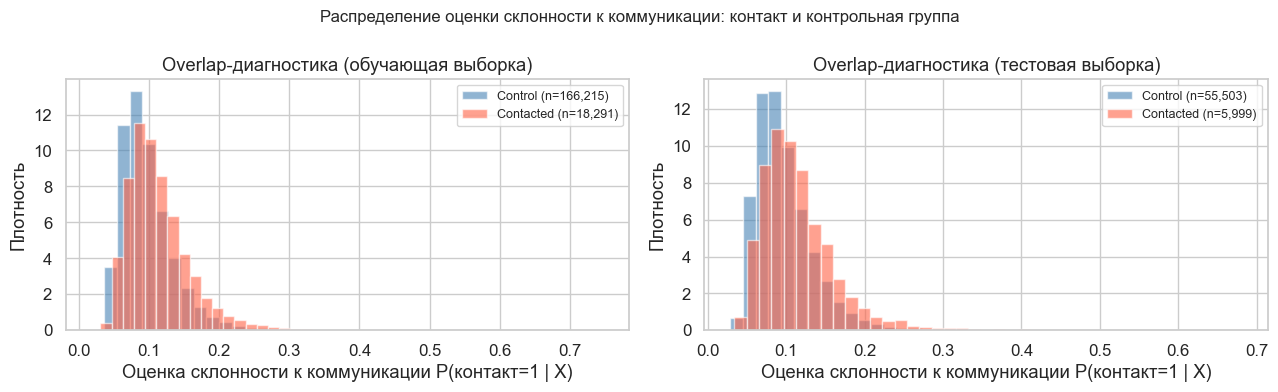


Признак                          Среднее (T)   Среднее (C)      SMD  Оценка
------------------------------------------------------------------------
BASE_PD                               0.1879        0.0687    0.639  !!! >0.2
EXT_SOURCE_1                          0.4203        0.5117   -0.431  !!! >0.2
EXT_SOURCE_2                          0.4567        0.5205   -0.317  !!! >0.2
EXT_SOURCE_3                          0.4417        0.5183   -0.383  !!! >0.2
AMT_CREDIT                       725176.3844   584020.3880    0.336  !!! >0.2
AMT_INCOME_TOTAL                 181404.3790   167004.6230    0.131  ~ 0.1-0.2
DAYS_BIRTH                       -15367.9765   -16115.7163    0.172  ~ 0.1-0.2
DAYS_EMPLOYED                     50611.7380    65586.8414   -0.110  ~ 0.1-0.2
AGE_YEARS                            42.1040       44.1526   -0.172  ~ 0.1-0.2
CREDIT_HISTORY_LENGTH              1264.5769     1272.9923   -0.009  OK <0.1
EMPLOYMENT_RATIO                     -2.3334       -2.9976    0.104

In [50]:
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.preprocessing import StandardScaler as _SS

# --- Оценка склонности к коммуникации: P(контакт=1 | X) через логистическую регрессию на числовых признаках ---
_t_tr = (train['COMMUNICATION'] != 'control').astype(int).values
_ps_feats = [f for f in feature_cols if f in train.columns
             and train[f].dtype != object][:25]

_scaler = _SS()
_X_tr = _scaler.fit_transform(train[_ps_feats].fillna(-999))
_X_te = _scaler.transform(test[_ps_feats].fillna(-999))

_ps_lr = _LR(max_iter=500, C=0.1, random_state=RANDOM_SEED)
_ps_lr.fit(_X_tr, _t_tr)
ps_train = _ps_lr.predict_proba(_X_tr)[:, 1]
ps_test  = _ps_lr.predict_proba(_X_te)[:, 1]

# --- График распределения оценки склонности к коммуникации ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ps, t_arr, split in [
    (axes[0], ps_train, _t_tr,        'обучающая выборка'),
    (axes[1], ps_test,  t_test_bin,   'тестовая выборка'),
]:
    ax.hist(ps[t_arr == 0], bins=40, alpha=0.6, density=True,
            label=f'Control (n={(t_arr==0).sum():,})', color='steelblue')
    ax.hist(ps[t_arr == 1], bins=40, alpha=0.6, density=True,
            label=f'Contacted (n={(t_arr==1).sum():,})', color='tomato')
    ax.set_xlabel('Оценка склонности к коммуникации P(контакт=1 | X)')
    ax.set_ylabel('Плотность')
    ax.set_title(f'Overlap-диагностика ({split})')
    ax.legend(fontsize=9)
plt.suptitle('Распределение оценки склонности к коммуникации: контакт и контрольная группа', fontsize=12)
plt.tight_layout()
plt.show()

# --- SMD-таблица ---
_smd_feats = [f for f in [
    'BASE_PD', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AGE_YEARS', 'CREDIT_HISTORY_LENGTH', 'EMPLOYMENT_RATIO',
] if f in train.columns]

print(f"\n{'Признак':<30} {'Среднее (T)':>13} {'Среднее (C)':>13} {'SMD':>8}  Оценка")
print('-' * 72)
for feat in _smd_feats:
    t_v = train.loc[train['COMMUNICATION'] != 'control', feat].dropna()
    c_v = train.loc[train['COMMUNICATION'] == 'control', feat].dropna()
    smd = (t_v.mean() - c_v.mean()) / (np.sqrt((t_v.var() + c_v.var()) / 2) + 1e-12)
    flag = 'OK <0.1' if abs(smd) < 0.1 else ('~ 0.1-0.2' if abs(smd) < 0.2 else '!!! >0.2')
    print(f"{feat:<30} {t_v.mean():>13.4f} {c_v.mean():>13.4f} {smd:>8.3f}  {flag}")

print("\nВывод: значительный SMD по BASE_PD и EXT_SOURCE отражает намеренное смещение выборки "
      "(смещение отбора): высокорисковые клиенты систематически попадают в группу воздействия.")

# --- SMD после IPTW (Inverse Probability Treatment Weighting) ---
# Treated: w = 1/ps,  Control: w = 1/(1-ps)  (нормализуем внутри группы)
_w_t = 1.0 / (ps_train[_t_tr == 1] + 1e-8)
_w_c = 1.0 / (1 - ps_train[_t_tr == 0] + 1e-8)
_w_t /= _w_t.sum()
_w_c /= _w_c.sum()

print(f"{'Признак':<30} {'SMD (до)':>10} {'SMD (после)':>12}  Изменение")
print('-' * 68)
for feat in _smd_feats:
    _t_v = train.loc[train['COMMUNICATION'] != 'control', feat].fillna(-999).values
    _c_v = train.loc[train['COMMUNICATION'] == 'control', feat].fillna(-999).values

    # Невзвешенный SMD
    _smd_raw = ((_t_v.mean() - _c_v.mean())
                / (np.sqrt((_t_v.var() + _c_v.var()) / 2) + 1e-12))

    # Взвешенный SMD (IPTW)
    _mt_w = np.average(_t_v, weights=_w_t)
    _mc_w = np.average(_c_v, weights=_w_c)
    _vt_w = np.average((_t_v - _mt_w) ** 2, weights=_w_t)
    _vc_w = np.average((_c_v - _mc_w) ** 2, weights=_w_c)
    _smd_w = (_mt_w - _mc_w) / (np.sqrt((_vt_w + _vc_w) / 2) + 1e-12)

    _delta = abs(_smd_raw) - abs(_smd_w)
    _arr   = 'улучш.' if _delta > 0 else 'хуже'
    print(f"{feat:<30} {_smd_raw:>10.3f} {_smd_w:>12.3f}  {_arr} ({_delta:+.3f})")

print("Вывод: IPTW снижает SMD, но не устраняет смещение полностью —")
print("детерминированное назначение каналов по квантилям риска создаёт")
print("почти идеальное нарушение условия positivity (overlap violation).")

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по диагностике сопоставимости групп.</b>

<p><b>1. Группы изначально не сопоставимы.</b></p>

По графикам propensity score видно, что вероятность попасть в коммуникацию зависит от клиентского профиля, а не распределена случайно. Банк чаще воздействовал на клиентов с более выраженными признаками риска. Это соответствует реалистичной банковской политике коммуникаций, но для обучения uplift-моделей создает риск смещения: модель может принять исходные различия между группами за эффект коммуникации.

<p><b>2. SMD подтверждает перекос количественно.</b></p>

Наиболее сильный дисбаланс наблюдается по `BASE_PD`: средний базовый риск в contacted-группе заметно выше, чем в control, а SMD равен 0.639, что существенно превышает стандартный порог 0.2. Аналогичный перекос виден по `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` и `AMT_CREDIT`: contacted-клиенты выглядят более рискованными и имеют иной кредитный профиль.

Следовательно, простое сравнение default rate между группами было бы некорректным: часть разницы в исходах объяснялась бы не эффектом коммуникации, а исходным составом групп.

<p><b>3. IPTW показывает, какую часть смещения можно ослабить.</b></p>

IPTW-взвешивание заметно улучшает баланс по большинству признаков: например, дисбаланс по `AMT_CREDIT`, доходу, возрасту и стажу практически уходит. Это означает, что в исходных данных есть области, где contacted- и control-клиенты достаточно похожи, и часть смещения можно компенсировать статистически: через веса, matching или ограничение выборки по propensity score.

При этом IPTW не изменяет сами данные: оно не удаляет клиентов, не меняет признаки и не переписывает target. В этом разделе оно используется как диагностический инструмент, который показывает, насколько группы могли бы стать ближе при корректировке вклада наблюдений.

<p><b>4. Полностью проблема не устраняется.</b></p>

Ключевой риск-фактор `BASE_PD` остается сильно несбалансированным даже после взвешивания: SMD снижается лишь с 0.639 до 0.600. Значит, проблема связана не только с небольшим перекосом выборки, а с самой логикой назначения коммуникации. Для части наиболее рискованных клиентов почти нет сопоставимых наблюдений в control-группе, поэтому в этих областях модель будет частично опираться на экстраполяцию.

<p><b>5. Методологический вывод.</b></p>

Данные содержат выраженное нарушение overlap/positivity. Поэтому uplift-модели в этом ноутбуке нужно интерпретировать осторожно: они полезны для сравнения стратегий и поиска сигнала, но оценки индивидуального эффекта в областях слабого overlap могут быть нестабильными.

Практически это означает, что перед внедрением uplift-подхода в реальной коммуникационной политике нужно контролировать качество дизайна данных: расширять контрольные группы, сохранять случайность назначения хотя бы внутри risk-сегментов и отдельно отслеживать overlap-диагностику. Без этого даже высокая AUUC/Qini-метрика может отражать не только качество uplift-ранжирования, но и историческое смещение политики коммуникаций.

</div>

<h2 id="uplift-qini-metrics">Метрики Qini и AUUC</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Qini-кривая и AUUC оценивают качество ранжирования клиентов по ожидаемой пользе коммуникации. В этой работе полезный эффект имеет отрицательный знак, потому что коммуникация снижает вероятность дефолта. Поэтому при ранжировании используется ориентация на большее предотвращение дефолта.

Метрика сравнивается с random baseline и logged-policy oracle, чтобы отделить реальный прирост от случайного выбора.

</div>


In [51]:
def compute_qini(y, treatment, score, n_bins=100):
    """Вычисляет Qini-кривую и AUUC для оценки качества uplift-ранжирования.

    Параметры
    ----------
    y : array-like
        Целевая переменная (1 = дефолт).
    treatment : array-like
        Бинарный флаг коммуникации (1 = контакт, 0 = контроль).
    score : array-like
        Скор ранжирования; клиенты сортируются по убыванию.
    n_bins : int, по умолчанию 100
        Число точек Qini-кривой.

    Возвращает
    ----------
    tuple[ndarray, ndarray, ndarray, float]
        (fracs, qini_vals, random_vals, auuc).
        fracs — доли охваченных клиентов; qini_vals — значения Qini;
        random_vals — базовая линия случайного ранжирования; auuc — площадь между кривой и этой базовой линией.
    """
    df_q = pd.DataFrame({'y': y, 't': treatment, 'score': score})
    df_q = df_q.sort_values('score', ascending=False).reset_index(drop=True)

    n_ctrl = int((1 - treatment).sum())
    if n_ctrl == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0]), np.array([0.0, 0.0]), 0.0

    fracs, qini_vals = [0.0], [0.0]
    step = max(1, len(df_q) // n_bins)
    for k in range(step, len(df_q) + 1, step):
        top_k = df_q.iloc[:k]
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        if len(t0) == 0:
            continue
        qini = t1['y'].sum() - t0['y'].sum() * (len(t1) / n_ctrl)
        fracs.append(k / len(df_q))
        qini_vals.append(qini)

    full_qini = qini_vals[-1] if qini_vals else 0.0
    random_vals = [f * full_qini for f in fracs]
    auuc = np.trapz(qini_vals, fracs) - np.trapz(random_vals, fracs)
    return np.array(fracs), np.array(qini_vals), np.array(random_vals), auuc


<h2 id="uplift-basic-policies">Базовые стратегии отбора клиентов</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужен этот раздел.</b> Перед обучением uplift-моделей важно задать понятные ориентиры качества. Иначе сложно интерпретировать, является ли результат модели действительно хорошим: она может быть лучше случайного отбора, но все еще сильно уступать идеальному ранжированию, или наоборот — давать почти весь достижимый эффект.

<p><b>Какие стратегии сравниваются.</b></p>

<ul>
  <li><b>Случайный отбор</b> показывает результат кампании без интеллектуального ранжирования. Это нижний ориентир: если модель не превосходит случайный выбор, практической ценности в ней нет.</li>
  <li><b>Risk-based отбор</b> выбирает клиентов по прогнозному риску дефолта. Это сильный бизнес-baseline: такая стратегия понятна и легко внедряется, но она отвечает на вопрос «кто рискованнее», а не «на кого коммуникация подействует сильнее».</li>
  <li><b>Oracle-стратегии</b> используют информацию, недоступную в реальной кампании. Они нужны не для внедрения, а для оценки верхней границы: насколько далеко текущие модели находятся от идеального ранжирования.</li>
</ul>

<p><b>Почему важно различать два oracle.</b></p>

<ul>
  <li><b>Оракул по наблюдавшейся политике</b> использует только фактически реализованные исходы. Он ближе к реальным данным, но ограничен исторической политикой коммуникаций и проблемой overlap.</li>
  <li><b>Контрфактический оракул</b> использует истинный синтетический эффект `TRUE_UPLIFT`. То есть это "идеальная" политика, которая формируется благодаря тому, что "видит" все возможные ээфекты от коммуникаций и всегда выбирает лучший вариань. В реальной задаче такой информации нет, но в синтетическом стенде она позволяет понять предельный уровень качества при идеальном знании механизма воздействия.</li>
</ul>

<p><b>Как читать типологию клиентов.</b></p>

Типология помогает перейти от абстрактной метрики к управленческому смыслу:

<ul>
  <li><b>Persuadables / перспективные</b> — клиенты, у которых коммуникация снижает риск дефолта. Это основная целевая группа для кампании.</li>
  <li><b>Sure things / устойчивые</b> — клиенты, которые и без контакта с высокой вероятностью не уйдут в дефолт. Коммуникация с ними может быть избыточной.</li>
  <li><b>Sleeping dogs / чувствительные к раздражению</b> — клиенты, у которых контакт может ухудшить поведение. Их особенно важно не включать в кампанию.</li>
  <li><b>Lost causes / безразличные</b> — клиенты, поведение которых почти не меняется от коммуникации. Воздействие на них обычно неэффективно.</li>
</ul>

<b>Главный акцент.</b> Этот раздел задает шкалу для последующего сравнения: uplift-модель должна быть не просто точной как risk-модель, а лучше распределять коммуникацию между типами клиентов — чаще выбирать тех, кому контакт помогает, и реже тех, кому он бесполезен или вреден.

</div>

In [52]:
rng = np.random.RandomState(RANDOM_SEED)

scores_baselines = {
    'Случайный выбор':                rng.rand(len(y_test)),
    'BASE_PD (синтетич.)':            test['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_test,
    'CatBoost (все feat, TARGET)':    cb_all_score_test,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_test,
    'LogReg (все feat, TARGET)':      lr_all_score_test,
    'Logged-policy oracle':          -test['TRUE_UPLIFT'].values,
    'Counterfactual oracle':         -test['ORACLE_TRUE_UPLIFT'].values,
}
scores_baselines_oot = {
    'Случайный выбор':                np.random.RandomState(RANDOM_SEED+1).rand(len(y_oot)),
    'BASE_PD (синтетич.)':            oot['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_oot,
    'CatBoost (все feat, TARGET)':    cb_all_score_oot,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_oot,
    'LogReg (все feat, TARGET)':      lr_all_score_oot,
    'Logged-policy oracle':          -oot['TRUE_UPLIFT'].values,
    'Counterfactual oracle':         -oot['ORACLE_TRUE_UPLIFT'].values,
}

print(f'{"Стратегия":<35} {"AUUC (тест)":>12} {"AUUC (OOT)":>12}')
print('-' * 62)
baseline_auuc = {}
for name in scores_baselines:
    _, _, _, auuc_t = compute_qini(y_test, t_test_bin, scores_baselines[name])
    _, _, _, auuc_o = compute_qini(y_oot,  t_oot_bin,  scores_baselines_oot[name])
    baseline_auuc[name] = auuc_t
    print(f'{name:<35} {auuc_t:>12.6f} {auuc_o:>12.6f}')

Стратегия                            AUUC (тест)   AUUC (OOT)
--------------------------------------------------------------
Случайный выбор                        62.697420    74.981443
BASE_PD (синтетич.)                   365.925462   371.233102
CatBoost (22-отобр., TARGET)          175.179641   201.587124
CatBoost (все feat, TARGET)           239.525812   267.029861
LogReg (8 WoE, TARGET)                184.434573   187.429118
LogReg (все feat, TARGET)             236.173994   261.233413
Logged-policy oracle                  413.920719   419.021429
Counterfactual oracle                 285.285277   272.798262


<h3 id="uplift-policy-summary">Выводы по базовым стратегиям отбора</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по базовым стратегиям.</b> Базовые стратегии задают шкалу, относительно которой дальше оцениваются uplift-модели. Случайный отбор показывает минимальный ориентир качества, risk-based стратегия показывает силу обычного кредитного скоринга, а oracle-стратегии задают верхнюю границу возможного результата.

<p><b>1. Risk-based стратегия является сильным baseline.</b></p>

Если клиенты с высоким кредитным риском одновременно чаще оказываются теми, на кого коммуникация влияет сильнее, то обычный risk-score может давать неплохое ранжирование даже без явного моделирования uplift. Это не ошибка эксперимента, а важный методологический результат: в кредитной задаче риск и эффект воздействия могут быть связаны.

<p><b>2. Но высокий риск не равен высокому uplift.</b></p>

Risk-based подход отвечает на вопрос «у кого выше вероятность дефолта», а uplift-подход — на вопрос «у кого вероятность дефолта сильнее изменится из-за коммуникации». Эти группы могут пересекаться, но не обязаны совпадать. Поэтому сильный risk-baseline не отменяет необходимости uplift-моделей: он задает планку, которую им нужно превзойти или хотя бы объяснимо приблизить.

<p><b>3. Oracle-ориентиры показывают запас для улучшения.</b></p>

Разрыв между risk-based стратегией и oracle показывает, сколько потенциального эффекта остается недоиспользованным при ранжировании только по риску. Если такой разрыв заметен, значит в данных есть информация о неоднородности эффекта коммуникации, которую специализированные uplift-модели могут попытаться извлечь.

<p><b>4. Как это влияет на дальнейший анализ.</b></p>

Дальше uplift-модели нужно оценивать не изолированно, а в сравнении с этими ориентирами:

<ul>
  <li>они должны быть лучше случайного отбора;</li>
  <li>желательно, чтобы они добавляли качество сверх risk-based ранжирования;</li>
  <li>их результат нужно сопоставлять с oracle, чтобы понимать, насколько близко модель подошла к достижимой верхней границе;</li>
  <li>если uplift-модель уступает risk-based стратегии, это не обязательно провал, но сигнал, что обычный риск в этой задаче уже несет значительную часть uplift-информации.</li>
</ul>

<b>Главный акцент.</b> Этот раздел показывает, что задача не сводится к построению «любой uplift-модели». Нужно проверить, дает ли uplift-моделирование дополнительную управленческую ценность по сравнению с простой и интерпретируемой стратегией отбора клиентов по риску.

</div>

<h2 id="uplift-modeling-intro">Переход к uplift-моделям</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем переходим к uplift-моделям.</b> Базовые стратегии показали, что risk-based ранжирование может быть сильным ориентиром, но оно не отвечает на главный вопрос коммуникационной политики: у какого клиента вероятность дефолта изменится именно из-за контакта. Поэтому дальше строятся модели индивидуального эффекта воздействия — uplift-модели.

<p><b>Что будет оцениваться.</b></p>

Целевая величина для uplift-подхода — не сам факт дефолта, а разница между двумя потенциальными исходами:

<ul>
  <li>что произошло бы с клиентом при коммуникации;</li>
  <li>что произошло бы с тем же клиентом без коммуникации.</li>
</ul>

В реальных данных одновременно наблюдается только один из этих исходов, поэтому uplift-модель должна восстановить контрфактический сценарий по данным treated/control-групп.

<p><b>Какие подходы будут построены.</b></p>

<ul>
  <li><b>S-Learner</b> — одна модель обучается на всех клиентах, а признак коммуникации добавляется как обычный feature. Эффект оценивается как разница предсказаний для одного и того же клиента при `treatment=1` и `treatment=0`.</li>
  <li><b>T-Learner</b> — две отдельные модели обучаются для contacted- и control-группы. Uplift считается как разница между прогнозом модели воздействия и прогнозом контрольной модели.</li>
  <li><b>X-Learner</b> — расширяет T-Learner: сначала оценивает недостающие индивидуальные эффекты внутри каждой группы, затем обучает модели этих эффектов и объединяет их с учетом propensity score.</li>
  <li><b>DR-Learner</b> — doubly robust подход, который сочетает outcome-модели и propensity score. Он полезен тем, что может частично снижать смещение, если хотя бы одна из частей модели специфицирована достаточно хорошо.</li>
</ul>

<p><b>Почему используются несколько алгоритмов.</b></p>

Разные uplift-подходы по-разному реагируют на дисбаланс групп, слабый overlap и связь риска с эффектом коммуникации. Поэтому один алгоритм не дает полной картины. Сравнение S-, T-, X- и DR-Learner позволяет понять, является ли найденный uplift-сигнал устойчивым или зависит от конкретной архитектуры модели.

<p><b>Как будут сравниваться модели.</b></p>

Дальше каждая модель будет оцениваться не только по качеству прогноза дефолта, а по качеству ранжирования клиентов для коммуникации: через Qini-кривые, AUUC, сравнение с risk-based baseline и oracle-ориентирами. Основной вопрос: дает ли uplift-модель дополнительную практическую ценность сверх обычного отбора по риску.

</div>

<h3 id="uplift-targets-note">Почему используются разные целевые переменные</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Методологическая оговорка про `TARGET` и `TARGET_AFTER_CONTACT`.</b>

<p><b>1. Что означает `TARGET`.</b></p>

`TARGET` — исходная целевая переменная кредитного риска. Она описывает дефолтный статус клиента без учета моделируемой коммуникационной кампании. На ней обучаются классические risk-based модели: CatBoost и логистическая регрессия. Такие модели отвечают на вопрос: <b>«у кого выше базовый риск дефолта?»</b>

<p><b>2. Что означает `TARGET_AFTER_CONTACT`.</b></p>

`TARGET_AFTER_CONTACT` — наблюдаемый outcome после фактически назначенной коммуникации. Именно эта переменная отражает результат уже с учетом того, был ли клиент в control-группе или получил один из каналов воздействия. Для uplift-задачи это основной outcome, потому что нас интересует не просто базовый риск, а изменение вероятности дефолта под воздействием коммуникации.

<p><b>3. Почему risk-модели обучаются на `TARGET`, а uplift-модели — на `TARGET_AFTER_CONTACT`.</b></p>

Risk-based модели имитируют обычный кредитный скоринг, который строится до коммуникационной политики и не знает будущего эффекта контакта. Поэтому для них честно использовать `TARGET`: это baseline, доступный банку до внедрения uplift-подхода.

Uplift-модели, наоборот, должны оценивать эффект воздействия. Для этого им нужен outcome, наблюдаемый после назначения коммуникации, то есть `TARGET_AFTER_CONTACT`. Именно по различиям в этом outcome между contacted- и control-группами модель пытается восстановить индивидуальный эффект контакта.

<p><b>4. Почему сравнение остается корректным.</b></p>

Модели обучаются на разных целевых переменных, потому что решают разные задачи:

<ul>
  <li>risk-модель оценивает базовый риск клиента;</li>
  <li>uplift-модель оценивает ожидаемое изменение риска из-за коммуникации.</li>
</ul>

Но сравниваются они не по train-target и не по AUC на разных целях. В финальном сравнении все стратегии оцениваются одинаково: как ранжирование клиентов для коммуникации через Qini/AUUC на одном и том же `TARGET_AFTER_CONTACT`, treatment-флаге и одинаковых test/OOT-выборках.

<p><b>5. Как правильно читать результаты.</b></p>

Если risk-based модель показывает высокий AUUC, это не значит, что она стала uplift-моделью. Это означает, что в данных базовый риск связан с эффектом коммуникации: более рискованные клиенты могут одновременно быть более чувствительными к контакту.

Если uplift-модель превосходит risk-based baseline, это говорит о дополнительной ценности uplift-подхода: модель использует не только информацию о риске, но и различия между сценариями «с коммуникацией» и «без коммуникации».

<b>Итог.</b> Использование разных target-переменных здесь не является некорректным сравнением. Это способ честно сопоставить две управленческие логики: классический отбор клиентов по риску и отбор клиентов по ожидаемому эффекту коммуникации.

</div>

<h2 id="uplift-s-learner">Единая модель с признаком воздействия (S-Learner)</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

S-Learner обучает одну модель исхода, где канал коммуникации является признаком. Его сила - использование всей выборки сразу. Его слабость - риск потерять слабый treatment effect на фоне сильного сигнала кредитного риска.

</div>


In [53]:
from catboost import CatBoostClassifier

# Кодируем канал коммуникации методом one-hot: каждый канал превращается в бинарный столбец COMM_<channel>.
# Обучение только на T_train: кодировщик не видит тестовую и вневременную выборки
comm_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
comm_encoder.fit(T_train.reshape(-1, 1))

def add_treatment_ohe(X_df, T_arr, encoder):
    """Присоединяет one-hot представление канала коммуникации к матрице признаков клиента."""
    t_enc = encoder.transform(T_arr.reshape(-1, 1))
    t_df  = pd.DataFrame(t_enc,
                          columns=[f'COMM_{c}' for c in encoder.categories_[0]],
                          index=range(len(X_df)))
    return pd.concat([X_df.reset_index(drop=True), t_df], axis=1)

print('Категории коммуникации:', comm_encoder.categories_[0].tolist())
print('Столбцы one-hot кодирования:', [f'COMM_{c}' for c in comm_encoder.categories_[0]])

Категории коммуникации: ['control', 'operator_call', 'robot_call', 'sms']
Столбцы one-hot кодирования: ['COMM_control', 'COMM_operator_call', 'COMM_robot_call', 'COMM_sms']


In [54]:
# Добавляем признаки канала коммуникации к матрицам признаков.
# S-Learner видит X и T одновременно — единая модель для всех каналов.
X_train_s = add_treatment_ohe(X_train, T_train, comm_encoder)
X_test_s  = add_treatment_ohe(X_test,  T_test,  comm_encoder)
X_oot_s   = add_treatment_ohe(X_oot,   T_oot,   comm_encoder)

print(f'Размерность X_train_s: {X_train_s.shape}  ')
print(f'(добавлено {X_train_s.shape[1] - X_train.shape[1]} OHE-колонки)')

s_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_SEED, verbose=0,
    eval_metric='AUC', early_stopping_rounds=50,
)
s_model.fit(X_train_s, y_train, eval_set=(X_test_s, y_test))

auc_s = roc_auc_score(y_test, s_model.predict_proba(X_test_s)[:, 1])
print(f'S-Learner AUC (тест): {auc_s:.4f}  |  Gini: {2*auc_s-1:.4f}')

Размерность X_train_s: (184506, 143)  
(добавлено 4 OHE-колонки)
S-Learner AUC (тест): 0.8281  |  Gini: 0.6562


In [55]:
channels_list = ['sms', 'robot_call', 'operator_call']

def s_learner_uplift_per_channel(model, X_df, encoder, channels):
    """Вычисляет индивидуальный эффект S-Learner: hat_tau_t(x) = hat_mu(x,t) - hat_mu(x,control).

    Для каждого клиента вычисляется контрфактуальный сценарий:
    - p_ctrl: вероятность дефолта без коммуникации
    - p_ch:   вероятность дефолта при канале ch
    Uplift = p_ch - p_ctrl (отрицательный -> коммуникация помогает).
    'best' = min по каналам (наибольшее снижение PD).
    """
    X_ctrl = add_treatment_ohe(X_df, np.array(['control'] * len(X_df)), encoder)
    p_ctrl = model.predict_proba(X_ctrl)[:, 1]
    uplift = {}
    for ch in channels:
        X_ch = add_treatment_ohe(X_df, np.array([ch] * len(X_df)), encoder)
        uplift[ch] = model.predict_proba(X_ch)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

In [56]:
uplift_s_test = s_learner_uplift_per_channel(s_model, X_test, comm_encoder, channels_list)
uplift_s_oot  = s_learner_uplift_per_channel(s_model, X_oot,  comm_encoder, channels_list)

# Оценка приоритета равна -uplift['best']: чем сильнее снижение вероятности дефолта, тем выше клиент в списке.
score_s_test = -uplift_s_test['best']
score_s_oot  = -uplift_s_oot['best']

_, _, _, auuc_s_test = compute_qini(y_test, t_test_bin, score_s_test)
_, _, _, auuc_s_oot  = compute_qini(y_oot,  t_oot_bin,  score_s_oot)
oracle_auuc = baseline_auuc['Logged-policy oracle']

print(f'S-Learner AUUC: тест={auuc_s_test:.6f}  |  OOT={auuc_s_oot:.6f}')
print(f'Относительная эффективность: {auuc_s_test/oracle_auuc*100:.1f}% от оракула')
for ch in channels_list:
    print(f'  Средний uplift ({ch}): {uplift_s_test[ch].mean():.5f}')

S-Learner AUUC: тест=335.498528  |  OOT=344.697454
Относительная эффективность: 81.1% от оракула
  Средний uplift (sms): -0.02027
  Средний uplift (robot_call): -0.03348
  Средний uplift (operator_call): 0.00882


<h3 id="uplift-s-summary">Выводы по S-Learner</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по S-Learner.</b>

<p><b>1. Что здесь проверялось.</b></p>

S-Learner оценивает вероятность дефолта одной общей моделью, добавляя тип коммуникации как обычный признак. После обучения для каждого клиента строятся контрфактические прогнозы: что модель предсказала бы без коммуникации и что она предсказала бы при каждом канале воздействия. Разница между этими прогнозами используется как оценка индивидуального эффекта коммуникации.

<p><b>2. Качество модели исхода высокое, но это не главный критерий.</b></p>

На тестовой выборке S-Learner показывает AUC = 0.8281 и Gini = 0.6562. Это означает, что модель хорошо предсказывает сам факт дефолта. Однако для uplift-задачи этого недостаточно: нас интересует не только способность предсказывать риск, но и способность правильно ранжировать клиентов по ожидаемому эффекту коммуникации.

<p><b>3. По AUUC S-Learner дает заметное преимущество над практическими risk-based моделями.</b></p>

S-Learner достигает AUUC = 335.50 на тестовой выборке и 344.70 на OOT. Это около 81.1% от logged-policy oracle. Такой результат выше, чем у практических risk-based моделей: CatBoost и LogReg, обученные на TARGET, дают заметно меньший AUUC. Значит, S-Learner действительно извлекает дополнительный сигнал из признака воздействия, а не просто повторяет обычное ранжирование клиентов по риску.

<p><b>4. Модель различает каналы коммуникации.</b></p>

Средний оцененный uplift показывает разную направленность каналов:

<ul>
  <li>`sms`: средний uplift = -0.02027;</li>
  <li>`robot_call`: средний uplift = -0.03348;</li>
  <li>`operator_call`: средний uplift = 0.00882.</li>
</ul>

Так как outcome — дефолт, отрицательный uplift означает снижение вероятности дефолта после коммуникации. Поэтому по оценке S-Learner `robot_call` и `sms` в среднем выглядят полезными, а `operator_call` — потенциально нежелательным или применимым только к отдельным сегментам.

<p><b>5. Что это дает для дальнейшего анализа.</b></p>

S-Learner показывает, что переход от risk-based подхода к uplift-постановке имеет смысл: модель начинает использовать информацию о типе воздействия и лучше ранжирует клиентов для коммуникации. При этом метод остается достаточно простым и устойчивым, потому что обучается на всей выборке сразу.

Главное ограничение S-Learner состоит в том, что единая модель может сглаживать различия между каналами. Если эффект коммуникации слабый по сравнению с сильным сигналом кредитного риска, модель может недооценивать неоднородность воздействия. Поэтому дальше важно проверить, дадут ли более специализированные meta-learner подходы дополнительное качество по сравнению с этой простой uplift-базой.

</div>

<h2 id="uplift-t-learner">Две модели для групп воздействия и контроля (T-Learner)</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

T-Learner обучает отдельные модели исхода для каналов и контроля. Это делает его гибким в multi-treatment постановке, но повышает требования к объему данных по каждому каналу.

</div>


In [57]:
# Обучаем по одной CatBoost-модели на каждую категорию коммуникации
t_models = {}
print('Обучение T-Learner: одна модель на каждый канал коммуникации')
for treatment_name in ['control'] + channels_list:
    mask = T_train == treatment_name
    n_tr = mask.sum()
    m = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                            random_seed=RANDOM_SEED, verbose=0)
    m.fit(X_train[mask], y_train[mask])
    t_models[treatment_name] = m
    mask_t = T_test == treatment_name
    if mask_t.sum() > 50:
        auc = roc_auc_score(y_test[mask_t], m.predict_proba(X_test[mask_t])[:, 1])
        print(f'  {treatment_name:<16}  n обуч.={n_tr:>6,}  AUC={auc:.4f}')
    else:
        print(f'  {treatment_name:<16}  n обуч.={n_tr:>6,}  (мало данных в тестовой выборке)')


Обучение T-Learner: одна модель на каждый канал коммуникации
  control           n обуч.=166,215  AUC=0.8122
  sms               n обуч.= 3,133  AUC=0.4681
  robot_call        n обуч.= 4,591  AUC=0.5404
  operator_call     n обуч.=10,567  AUC=0.7796


In [58]:
def t_learner_uplift(models, X_df, channels):
    """Вычисляет uplift T-Learner: hat_tau_t(x) = hat_mu_t(x) - hat_mu_0(x).

    Каждая модель обучалась только на своей группе воздействия.
    Uplift = разность предсказаний канальной и контрольной моделей.
    'best' = min по каналам.
    """
    p_ctrl = models['control'].predict_proba(X_df)[:, 1]
    uplift = {}
    for ch in channels:
        uplift[ch] = models[ch].predict_proba(X_df)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

In [59]:
uplift_t_test = t_learner_uplift(t_models, X_test, channels_list)
uplift_t_oot  = t_learner_uplift(t_models, X_oot,  channels_list)

score_t_test = -uplift_t_test['best']
score_t_oot  = -uplift_t_oot['best']

_, _, _, auuc_t_test = compute_qini(y_test, t_test_bin, score_t_test)
_, _, _, auuc_t_oot  = compute_qini(y_oot,  t_oot_bin,  score_t_oot)
print(f'T-Learner AUUC: тест={auuc_t_test:.6f}  |  OOT={auuc_t_oot:.6f}')
print(f'Относительная эффективность: {auuc_t_test/oracle_auuc*100:.1f}% от оракула')
for ch in channels_list:
    print(f'  Средний uplift ({ch}): {uplift_t_test[ch].mean():.5f}')

T-Learner AUUC: тест=359.811664  |  OOT=368.472751
Относительная эффективность: 86.9% от оракула
  Средний uplift (sms): -0.07628
  Средний uplift (robot_call): -0.06906
  Средний uplift (operator_call): 0.02911


<h3 id="uplift-t-summary">Выводы по T-Learner</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по T-Learner.</b>

<p><b>1. Что здесь проверялось.</b></p>

T-Learner строит отдельную модель исхода для control-группы и отдельные модели для каждого канала коммуникации. После этого uplift оценивается как разница между прогнозом канальной модели и прогнозом контрольной модели для одного и того же клиента. Такой подход напрямую моделирует сценарии «без коммуникации» и «с конкретным каналом коммуникации».

<p><b>2. Метод лучше разделяет канальные эффекты.</b></p>

В отличие от S-Learner, где тип воздействия является одним из признаков внутри общей модели, T-Learner дает каждому каналу собственную модель. Это делает подход более гибким: он может лучше уловить различия между `sms`, `robot_call` и `operator_call`, если эти каналы действительно по-разному влияют на вероятность дефолта.

<p><b>3. По AUUC T-Learner стал лучшим обученным uplift/meta-learner.</b></p>

T-Learner достигает AUUC = 359.81 на тестовой выборке и 368.47 на OOT, что соответствует 86.9% от logged-policy oracle. Это выше результата S-Learner: 335.50 на тесте и 344.70 на OOT. Также T-Learner заметно превосходит практические risk-based модели CatBoost и LogReg, обученные на `TARGET`.

Это означает, что раздельное моделирование control- и treatment-сценариев действительно дает дополнительную информацию для ранжирования клиентов по ожидаемому эффекту коммуникации.

<p><b>4. Канальные оценки стали более контрастными.</b></p>

Средний оцененный uplift по каналам:

<ul>
  <li>`sms`: средний uplift = -0.07628;</li>
  <li>`robot_call`: средний uplift = -0.06906;</li>
  <li>`operator_call`: средний uplift = 0.02911.</li>
</ul>

Так как outcome — дефолт, отрицательный uplift означает снижение вероятности дефолта после коммуникации. Поэтому T-Learner оценивает `sms` и `robot_call` как полезные в среднем, а `operator_call` — как канал, который в среднем может быть неэффективным или даже нежелательным для части клиентов. По сравнению с S-Learner различия между каналами выражены сильнее, что логично для метода с отдельными моделями.

<p><b>5. Главное ограничение — объем и баланс данных по каналам.</b></p>

Сила T-Learner одновременно является его слабостью. Каждая модель обучается только на своей подвыборке, поэтому качество зависит от числа наблюдений в каждом канале. В обучающей выборке `control` содержит 166 215 наблюдений, `operator_call` — 10 567, `robot_call` — 4 591, а `sms` — только 3 133. Из-за этого модели редких каналов могут быть менее устойчивыми.

Это видно и по AUC внутри каналов: для `sms` AUC = 0.4681, для `robot_call` AUC = 0.5404, тогда как для `control` AUC = 0.8122, а для `operator_call` AUC = 0.7796. Поэтому высокое итоговое AUUC T-Learner нужно читать вместе с диагностикой объема данных: метод хорошо работает в этом эксперименте, но требует достаточной представленности каждого канала.

<p><b>6. Что это дает для дальнейшего анализа.</b></p>

T-Learner показывает, что uplift-сигнал в данных не сводится к обычному прогнозу риска. Раздельное моделирование сценариев воздействия позволяет лучше ранжировать клиентов для коммуникации и приблизиться к oracle-ориентиру сильнее, чем S-Learner и практические risk-based модели.

Главный практический вывод: T-Learner является сильным кандидатом для коммуникационной политики, если банк может обеспечить достаточный объем и баланс наблюдений по каналам. Если же отдельные каналы представлены слабо, преимущество метода может стать нестабильным, и его нужно проверять на OOT, bootstrap-оценках и диагностике overlap.

</div>

<h2 id="uplift-x-learner">Уточненная двухэтапная модель (X-Learner)</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

X-Learner строит псевдоэффекты через недостающие контрфактические исходы. Теоретически он полезен при дисбалансе treatment/control, но качество зависит от точности промежуточных моделей.

</div>


In [60]:
from catboost import CatBoostRegressor

# Шаг 1: базовые модели исхода для бинарного воздействия.
mask_treat = t_train_bin == 1
mask_ctrl  = t_train_bin == 0

mu1_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu0_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu1_model.fit(X_train[mask_treat], y_train[mask_treat])
mu0_model.fit(X_train[mask_ctrl],  y_train[mask_ctrl])
print(f'mu1 (воздействие): {mask_treat.sum():,} клиентов  |  mu0 (контроль): {mask_ctrl.sum():,}')

# Шаг 2: псевдо-эффекты
d_treat = y_train[mask_treat] - mu0_model.predict_proba(X_train[mask_treat])[:, 1]
d_ctrl  = mu1_model.predict_proba(X_train[mask_ctrl])[:, 1] - y_train[mask_ctrl]
print(f'Псевдо-эффекты (воздействие): mean={d_treat.mean():.4f}  |  (контроль): mean={d_ctrl.mean():.4f}')


mu1 (воздействие): 18,291 клиентов  |  mu0 (контроль): 166,215
Псевдо-эффекты (воздействие): mean=-0.0061  |  (контроль): mean=-0.0033


In [61]:
# Шаг 3: регрессоры на псевдо-эффектах
# tau1 обучается на treated-группе (d_treat = y - mu0(x)),
# tau0 обучается на контрольной группе (d_ctrl = mu1(x) - y).
# Это "скрещивание" даёт X-Learner его имя.
tau1_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau0_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau1_model.fit(X_train[mask_treat], d_treat)
tau0_model.fit(X_train[mask_ctrl],  d_ctrl)
print(f'tau1 обучен на {mask_treat.sum():,} treated  |  tau0 на {mask_ctrl.sum():,} контрольных')

tau1 обучен на 18,291 treated  |  tau0 на 166,215 контрольных


In [62]:
# Шаг 4: score склонности к воздействию g(x) = P(T=1 | X=x).
# Взвешивание: hat_tau(x) = g(x)*hat_tau0(x) + (1-g(x))*hat_tau1(x)
# Клиенты с высоким g(x) похожи на treated -> доверяем tau0 больше.
prop_model = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=4,
                                 random_seed=RANDOM_SEED, verbose=0)
prop_model.fit(X_train, t_train_bin)

g_test = prop_model.predict_proba(X_test)[:, 1]
print(f'Склонность к воздействию (тест): среднее={g_test.mean():.4f}  |  ')
print(f'Доля коммуникации в обучающей выборке: {t_train_bin.mean():.4f}')

def x_learner_predict(tau1, tau0, prop, X):
    """Предсказывает CATE: propensity-взвешенное смешение tau0 и tau1."""
    g = prop.predict_proba(X)[:, 1]
    return g * tau0.predict(X) + (1 - g) * tau1.predict(X)

Склонность к воздействию (тест): среднее=0.0987  |  
Доля коммуникации в обучающей выборке: 0.0991


In [63]:
uplift_x_test = x_learner_predict(tau1_model, tau0_model, prop_model, X_test)
uplift_x_oot  = x_learner_predict(tau1_model, tau0_model, prop_model, X_oot)

score_x_test = -uplift_x_test
score_x_oot  = -uplift_x_oot

_, _, _, auuc_x_test = compute_qini(y_test, t_test_bin, score_x_test)
_, _, _, auuc_x_oot  = compute_qini(y_oot,  t_oot_bin,  score_x_oot)
print(f'X-Learner AUUC: тест={auuc_x_test:.6f}  |  OOT={auuc_x_oot:.6f}')
print(f'Относительная эффективность: {auuc_x_test/oracle_auuc*100:.1f}% от оракула')
print(f'Средний uplift на тестовой выборке: {uplift_x_test.mean():.5f}')

X-Learner AUUC: тест=153.683645  |  OOT=116.699063
Относительная эффективность: 37.1% от оракула
Средний uplift на тестовой выборке: -0.00678


<h3 id="uplift-x-summary">Выводы по X-Learner</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по X-Learner.</b>

<p><b>1. Что здесь проверялось.</b></p>

X-Learner строит оценку индивидуального эффекта в несколько этапов. Сначала обучаются outcome-модели для treatment- и control-группы, затем для каждой группы восстанавливаются недостающие контрфактические исходы. На их основе строятся псевдоэффекты, после чего отдельные модели пытаются предсказывать эти псевдоэффекты по признакам клиента.

Идея метода состоит в том, чтобы лучше использовать информацию из несбалансированных групп: например, когда control-группа существенно больше treatment-группы или наоборот.

<p><b>2. В текущей постановке преимущество не появилось.</b></p>

X-Learner показывает AUUC = 153.68 на тестовой выборке и 116.70 на OOT, что соответствует только 37.1% от logged-policy oracle. Это ниже S-Learner, T-Learner и даже практических risk-based моделей CatBoost/LogReg. Следовательно, в данном эксперименте X-Learner не улучшает ранжирование клиентов для коммуникации.

<p><b>3. Связь с истинным эффектом практически отсутствует.</b></p>

При проверке на `TRUE_UPLIFT` коэффициент Спирмена для X-Learner равен -0.0023 при p-value = 0.5644. Это означает, что предсказанный X-Learner порядок клиентов почти не связан с истинным порядком по эффекту коммуникации. Иными словами, модель не просто дает низкий AUUC, а слабо восстанавливает саму структуру индивидуального эффекта.

<p><b>4. Почему так могло произойти.</b></p>

Вероятная причина — накопление ошибок на нескольких этапах. X-Learner сначала зависит от качества outcome-моделей, затем от качества псевдоэффектов, а затем от моделей, которые эти псевдоэффекты предсказывают. Если эффект коммуникации слабый, данные шумные, а treatment-группа меньше control-группы, то псевдоэффекты могут стать слишком нестабильной целью для обучения.

В этом эксперименте treatment-группа содержит 18 291 наблюдение, а control-группа — 166 215. Формально X-Learner как раз рассчитан на такие дисбалансы, но при слабом и неоднородном эффекте самого увеличения сложности оказывается недостаточно.

<p><b>5. Что это дает для дальнейшего анализа.</b></p>

Результат X-Learner полезен как отрицательный контроль сложности. Он показывает, что более продвинутый causal-алгоритм не обязан выигрывать автоматически. Если промежуточные counterfactual-оценки шумные, многоэтапная схема может ухудшить итоговое ранжирование по сравнению с более простыми S- и T-Learner.

Практический вывод: в этой постановке X-Learner не стоит выбирать как основную модель коммуникационной политики. Его результат лучше использовать как аргумент в пользу того, что качество uplift-модели определяется не только теоретической сложностью алгоритма, но и структурой данных: overlap, балансом каналов, силой treatment effect и стабильностью промежуточных моделей.

</div>

<h2 id="uplift-dr-learner">Модель с двойной робастностью (DR-Learner)</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

DR-Learner сочетает модель исхода и модель вероятности воздействия. Его теоретическое преимущество проявляется при хороших nuisance-моделях и достаточном overlap.

</div>


In [64]:
# DR-Learner: вневыборочные прогнозы исхода и склонности к воздействию через пятикратную перекрестную проверку
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_train_arr = X_train.values
mu1_oof = np.zeros(len(X_train_arr))
mu0_oof = np.zeros(len(X_train_arr))
e_oof   = np.zeros(len(X_train_arr))

print('DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...')
for fold, (idx_tr, idx_val) in enumerate(kf.split(X_train_arr)):
    X_f, X_v = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_f, t_f = y_train[idx_tr], t_train_bin[idx_tr]

    # Модель исхода: добавляем бинарный признак коммуникации
    X_f_aug  = np.column_stack([X_f, t_f])
    X_v_aug1 = np.column_stack([X_v, np.ones(len(X_v))])
    X_v_aug0 = np.column_stack([X_v, np.zeros(len(X_v))])
    mu_tmp = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                 random_seed=RANDOM_SEED, verbose=0)
    mu_tmp.fit(X_f_aug, y_f)
    mu1_oof[idx_val] = mu_tmp.predict_proba(X_v_aug1)[:, 1]
    mu0_oof[idx_val] = mu_tmp.predict_proba(X_v_aug0)[:, 1]

    # Propensity model
    e_tmp = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                random_seed=RANDOM_SEED, verbose=0)
    e_tmp.fit(X_f, t_f)
    e_oof[idx_val] = e_tmp.predict_proba(X_v)[:, 1]
    print(f'  Fold {fold+1}/5', end='\r')

print('\nOut-of-fold предсказания готовы.')
print(f'  mu1: mean={mu1_oof.mean():.4f}  |  mu0: mean={mu0_oof.mean():.4f}  |  e: mean={e_oof.mean():.4f}')


DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...
  Fold 5/5
Out-of-fold предсказания готовы.
  mu1: mean=0.0813  |  mu0: mean=0.0769  |  e: mean=0.0995


In [65]:
# DR псевдо-исходы: doubly robust score каузального эффекта
# dr(x) = (mu1(x) - mu0(x))  +  IPW-поправка
# IPW-поправка: (T - e(x)) / (e(x)*(1-e(x))) * (Y - mu_at_obs)
# При правильной хотя бы одной модели (исхода или propensity) score несмещена.
e_clipped  = np.clip(e_oof, 0.05, 0.95)   # клиппинг предотвращает деление на ~0
ipw_weight = (t_train_bin - e_clipped) / (e_clipped * (1 - e_clipped))
mu_at_obs  = t_train_bin * mu1_oof + (1 - t_train_bin) * mu0_oof
dr_pseudo  = (mu1_oof - mu0_oof) + ipw_weight * (y_train - mu_at_obs)

print(f'DR псевдо-исходы: mean={dr_pseudo.mean():.5f}, std={dr_pseudo.std():.5f}')
print(f'Доля с отрицательным эффектом (коммуникация помогает): {(dr_pseudo < 0).mean():.1%}')
print('Высокое стандартное отклонение ожидаемо из-за IPW-дисперсии при слабом сигнале.')

DR псевдо-исходы: mean=-0.00485, std=0.70545
Доля с отрицательным эффектом (коммуникация помогает): 14.5%
Высокое стандартное отклонение ожидаемо из-за IPW-дисперсии при слабом сигнале.


In [66]:
# Финальная регрессия: CatBoostRegressor учит dr_pseudo -> hat_tau(x)
dr_final = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
dr_final.fit(X_train_arr, dr_pseudo)

uplift_dr_test = dr_final.predict(X_test.values)
uplift_dr_oot  = dr_final.predict(X_oot.values)

score_dr_test = -uplift_dr_test
score_dr_oot  = -uplift_dr_oot

_, _, _, auuc_dr_test = compute_qini(y_test, t_test_bin, score_dr_test)
_, _, _, auuc_dr_oot  = compute_qini(y_oot,  t_oot_bin,  score_dr_oot)
print(f'DR-Learner AUUC: тест={auuc_dr_test:.6f}  |  OOT={auuc_dr_oot:.6f}')
print(f'Относительная эффективность: {auuc_dr_test/oracle_auuc*100:.1f}% от оракула')

DR-Learner AUUC: тест=141.514437  |  OOT=108.663152
Относительная эффективность: 34.2% от оракула


<h3 id="uplift-dr-summary">Выводы по DR-Learner</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по DR-Learner.</b>

<p><b>1. Что здесь проверялось.</b></p>

DR-Learner использует doubly robust подход: он сочетает модель исхода и модель вероятности попасть в коммуникацию. Сначала строятся вневыборочные прогнозы потенциальных исходов `mu1(x)` и `mu0(x)`, а также propensity score `e(x)`. Затем формируется DR-псевдоисход, который объединяет разность outcome-прогнозов и IPW-поправку на фактически наблюдавшийся исход.

Теоретическое преимущество подхода состоит в том, что оценка может оставаться устойчивой, если хотя бы одна из двух частей — outcome-модель или propensity-модель — достаточно хорошо описывает данные.

<p><b>2. В текущем эксперименте метод оказался слабым.</b></p>

DR-Learner показывает AUUC = 141.51 на тестовой выборке и 108.66 на OOT, что соответствует только 34.2% от logged-policy oracle. Это ниже S-Learner, T-Learner, X-Learner и практических risk-based моделей. Следовательно, в этой конфигурации DR-Learner не дает качественного ранжирования клиентов для коммуникации.

<p><b>3. Псевдоисходы получились шумными.</b></p>

DR-псевдоисход имеет среднее -0.00485 и стандартное отклонение 0.70545. Для задачи, где сам эффект коммуникации относительно небольшой, такое стандартное отклонение очень велико. Это означает, что финальная регрессионная модель обучается на сильно зашумленной цели: полезный uplift-сигнал теряется на фоне дисперсии IPW-поправки.

Дополнительно только 14.5% DR-псевдоисходов имеют отрицательный знак, то есть соответствуют снижению вероятности дефолта после коммуникации. Это усиливает ощущение, что сигнал о полезном воздействии в DR-таргете получился слабым и нестабильным.

<p><b>4. Связь с истинным эффектом не подтверждается.</b></p>

При проверке на `TRUE_UPLIFT` коэффициент Спирмена для DR-Learner равен 0.0066 при p-value = 0.1015. Такая связь статистически незначима и практически близка к нулю. Значит, предсказания DR-Learner почти не восстанавливают истинный порядок клиентов по эффекту коммуникации, что согласуется с низким AUUC.

<p><b>5. Почему doubly robust подход не сработал здесь.</b></p>

Название doubly robust не означает, что метод автоматически устойчив в любых данных. Для него критичны:

<ul>
  <li>достаточный overlap между contacted- и control-группами;</li>
  <li>качественная propensity-модель;</li>
  <li>качественные outcome-модели;</li>
  <li>умеренная дисперсия IPW-поправки;</li>
  <li>достаточно сильный treatment effect относительно шума.</li>
</ul>

В этом ноутбуке ранее уже была показана проблема overlap/positivity: коммуникация назначалась селективно, а группы не были полностью сопоставимы. Поэтому IPW-компонента может резко увеличивать дисперсию, а итоговый DR-псевдоисход становится сложной и шумной целью для обучения.

<p><b>6. Что это дает для дальнейшего анализа.</b></p>

Результат DR-Learner важен как практическое предупреждение. Более сложный causal-метод не заменяет диагностику данных и не исправляет автоматически слабый overlap, дисбаланс каналов или слабый сигнал воздействия. В текущей постановке DR-Learner не стоит выбирать как основную модель, но его слабый результат помогает показать границы применимости сложных причинных оценок.

Главный вывод для диссертации: внедрение uplift-подхода начинается не с выбора самого продвинутого алгоритма, а с проверки дизайна данных, качества контрольной группы, overlap и устойчивости промежуточных моделей.

</div>

<h2 id="uplift-risk-effect-check">Контрольная проверка: согласованность риска и эффекта</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Этот блок фиксирует центральную проблему работы. Если высокий риск совпадает с высокой полезностью коммуникации, risk-based стратегия может выглядеть почти как uplift-модель. Поэтому результаты нужно интерпретировать через связь риска и эффекта, а не только через место модели в таблице.

</div>


<h2 id="uplift-model-comparison">Сравнение моделей</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Сравнение включает четыре уровня: random baseline, risk-based стратегии, обученные uplift-модели и logged-policy oracle. Такая структура не дает перепутать качество модели с недостижимым знанием истинного эффекта.

</div>


In [67]:
true_uplift_test = test['TRUE_UPLIFT'].values
results = []

model_configs = [
    ('Случайный выбор',               scores_baselines['Случайный выбор'],
                                      np.zeros(len(y_test)),              'Базовый ориентир'),
    ('BASE_PD (синтетич.)',            scores_baselines['BASE_PD (синтетич.)'],
                                      test['BASE_PD'].values,             'Базовый ориентир'),
    ('CatBoost (22-отобр., TARGET)',   cb_saved_score_test,
                                      cb_saved_score_test,                'Risk'),
    ('CatBoost (все feat, TARGET)',    cb_all_score_test,
                                      cb_all_score_test,                  'Risk'),
    ('LogReg (8 WoE, TARGET)',         lr_saved_score_test,
                                      lr_saved_score_test,                'Risk'),
    ('LogReg (все feat, TARGET)',      lr_all_score_test,
                                      lr_all_score_test,                  'Risk'),
    ('Logged-policy oracle',           scores_baselines['Logged-policy oracle'],
                                      -true_uplift_test,                  'Базовый ориентир'),
    ('Counterfactual oracle',          scores_baselines['Counterfactual oracle'],
                                      -test['ORACLE_TRUE_UPLIFT'].values, 'Базовый ориентир'),
    ('S-Learner',                      score_s_test,  uplift_s_test['best'], 'Uplift'),
    ('T-Learner',                      score_t_test,  uplift_t_test['best'], 'Uplift'),
    ('X-Learner',                      score_x_test,  uplift_x_test,         'Uplift'),
    ('DR-Learner',                     score_dr_test, uplift_dr_test,        'Uplift'),
]

oracle_auuc = baseline_auuc['Logged-policy oracle']
for name, score, uplift_pred, mtype in model_configs:
    _, _, _, auuc = compute_qini(y_test, t_test_bin, score)
    sp_rho, sp_p  = stats.spearmanr(uplift_pred, true_uplift_test)
    results.append({'Модель': name, 'AUUC': auuc,
                    '% от оракула': auuc / oracle_auuc * 100,
                    'коэффициент Спирмена': sp_rho, 'p-value': sp_p, 'Тип': mtype})

df_results = pd.DataFrame(results).set_index('Модель')
print(df_results.sort_values('AUUC', ascending=False).to_string(
    float_format=lambda x: f'{x:.4f}'))

                                 AUUC  % от оракула  коэффициент Спирмена  p-value               Тип
Модель                                                                                              
Logged-policy oracle         413.9207      100.0000               -1.0000   0.0000  Базовый ориентир
BASE_PD (синтетич.)          365.9255       88.4047               -0.2174   0.0000  Базовый ориентир
T-Learner                    359.8117       86.9277                0.2052   0.0000            Uplift
S-Learner                    335.4985       81.0538                0.2000   0.0000            Uplift
Counterfactual oracle        285.2853       68.9227               -0.1914   0.0000  Базовый ориентир
CatBoost (все feat, TARGET)  239.5258       57.8676               -0.1321   0.0000              Risk
LogReg (все feat, TARGET)    236.1740       57.0578               -0.1217   0.0000              Risk
LogReg (8 WoE, TARGET)       184.4346       44.5579               -0.0714   0.0000         

<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Как читать таблицу сравнения.</b> Смотрите не только на абсолютный AUUC, но и на группы моделей: random baseline, risk-based, meta-learners и oracle. Это не одна линейка алгоритмов, а разные уровни доступной информации.

</div>


<h3 id="uplift-comparison-summary">Выводы по сравнительной таблице моделей</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по сравнительной таблице моделей.</b>

<p><b>1. Лучшие обученные uplift-модели — T-Learner и S-Learner.</b></p>

Среди моделей, которые реально обучаются на данных, лучший результат показывает T-Learner: AUUC = 359.81, или 86.9% от logged-policy oracle. S-Learner занимает второе место среди uplift-моделей: AUUC = 335.50, или 81.1% от oracle. Оба подхода заметно превосходят практические risk-based модели CatBoost и LogReg, обученные на `TARGET`.

Это означает, что uplift-постановка действительно добавляет управленческую ценность: модели используют не только информацию о базовом риске, но и различия между сценариями с коммуникацией и без коммуникации.

<p><b>2. T-Learner выигрывает за счет раздельного моделирования сценариев.</b></p>

Преимущество T-Learner над S-Learner согласуется с логикой методов. S-Learner использует единую модель и может сглаживать слабый treatment effect на фоне сильного кредитного риска. T-Learner строит отдельные outcome-модели для control- и treatment-сценариев, поэтому лучше выделяет неоднородность эффекта коммуникации.

При этом преимущество T-Learner нужно читать вместе с ограничениями: метод чувствительнее к объему данных по отдельным каналам и к качеству overlap.

<p><b>3. Практические risk-based модели уступают uplift-подходам.</b></p>

CatBoost на всех признаках дает AUUC = 239.53, LogReg на всех признаках — 236.17. Это примерно 58% и 57% от oracle соответственно. Такие результаты лучше случайного выбора, но заметно ниже S- и T-Learner.

Следовательно, обычный прогноз риска действительно содержит полезный сигнал для коммуникационной политики, но не извлекает весь эффект воздействия. Высокий риск клиента не всегда означает, что именно этому клиенту коммуникация поможет сильнее всего.

<p><b>4. `BASE_PD` остается очень сильным синтетическим ориентиром.</b></p>

`BASE_PD` показывает AUUC = 365.93, или 88.4% от oracle, и оказывается даже немного выше T-Learner. Это важный методологический результат, а не ошибка эксперимента. В синтетическом стенде механизм генерации связывает базовый риск и эффект коммуникации, поэтому риск может частично имитировать uplift-ранжирование.

Однако `BASE_PD` нельзя интерпретировать как обычную production-модель: это синтетическая переменная, близкая к механизму генерации данных. Поэтому основной практический benchmark — не `BASE_PD`, а обученные risk-based модели CatBoost и LogReg.

<p><b>5. Сложные causal-подходы не гарантируют выигрыша.</b></p>

X-Learner и DR-Learner показывают заметно более слабые результаты: AUUC = 153.68 и 141.51 соответственно. Их слабый результат согласуется с предыдущей диагностикой: при слабом эффекте, дисбалансе групп, проблемах overlap и шумных псевдоисходах многоэтапные методы могут накапливать ошибку вместо улучшения ранжирования.

<p><b>6. Как читать итоговое сравнение.</b></p>

Главный вывод таблицы не в том, что «любой uplift лучше любого risk-score». Более точная интерпретация такая:

<ul>
  <li>простые uplift-подходы S- и T-Learner дают практическое преимущество над обученными risk-based моделями;</li>
  <li>T-Learner является лучшим обученным meta-learner в основном эксперименте;</li>
  <li>сильный результат `BASE_PD` показывает, что связь риска и эффекта может делать риск-ориентированную стратегию очень конкурентной;</li>
  <li>X-Learner и DR-Learner демонстрируют, что сложность алгоритма сама по себе не гарантирует качества;</li>
  <li>вывод о пользе uplift-моделей должен сопровождаться диагностикой overlap, устойчивости и структуры данных.</li>
</ul>

<b>Итог.</b> В этом эксперименте uplift-моделирование дает дополнительную ценность по сравнению с практическими risk-based моделями, но эта ценность проявляется не автоматически. Ее нужно подтверждать сравнением с baselines, oracle-ориентирами и диагностикой данных.

</div>

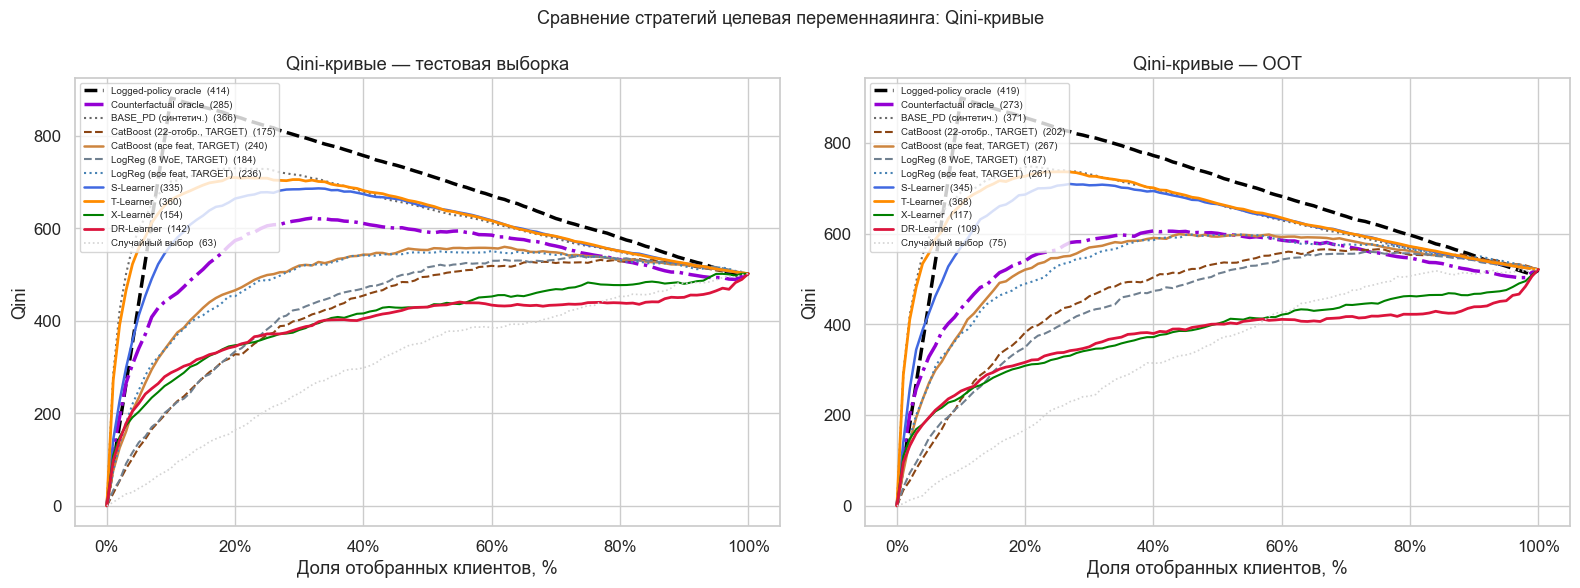

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_styles = [
    ('Logged-policy oracle',         'black',      '--', 2.5),
    ('Counterfactual oracle',        'darkviolet', '-.',  2.5),
    ('BASE_PD (синтетич.)',          'dimgray',    ':',  1.5),
    ('CatBoost (22-отобр., TARGET)', 'saddlebrown','--', 1.5),
    ('CatBoost (все feat, TARGET)',  'peru',       '-',  1.8),
    ('LogReg (8 WoE, TARGET)',       'slategray',  '--', 1.5),
    ('LogReg (все feat, TARGET)',    'steelblue',  ':',  1.5),
    ('S-Learner',                    'royalblue',  '-',  1.8),
    ('T-Learner',                    'darkorange', '-',  2.0),
    ('X-Learner',                    'green',      '-',  1.5),
    ('DR-Learner',                   'crimson',    '-',  2.0),
    ('Случайный выбор',              'lightgray',  ':',  1.2),
]

score_map_test = {
    **scores_baselines,
    'S-Learner':  score_s_test,
    'T-Learner':  score_t_test,
    'X-Learner':  score_x_test,
    'DR-Learner': score_dr_test,
}
score_map_oot = {
    **scores_baselines_oot,
    'S-Learner':  score_s_oot,
    'T-Learner':  score_t_oot,
    'X-Learner':  score_x_oot,
    'DR-Learner': score_dr_oot,
}

for ax, (y_arr, t_arr, sc_map, suffix) in zip(axes, [
    (y_test, t_test_bin, score_map_test, 'тестовая выборка'),
    (y_oot,  t_oot_bin,  score_map_oot,  'OOT'),
]):
    for label, color, ls, lw in plot_styles:
        if label not in sc_map:
            continue
        fracs, qini, _, auuc = compute_qini(y_arr, t_arr, sc_map[label])
        ax.plot(fracs * 100, qini, color=color, linestyle=ls, linewidth=lw,
                label=f'{label}  ({auuc:.0f})')
    ax.set_xlabel('Доля отобранных клиентов, %')
    ax.set_ylabel('Qini')
    ax.set_title(f'Qini-кривые — {suffix}')
    ax.legend(loc='upper left', fontsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Сравнение стратегий целевая переменнаяинга: Qini-кривые', fontsize=13)
plt.tight_layout()
plt.show()

<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#d8d8e8; border-style:solid; border-radius:6px">

<b>Рисунок. Сравнение Qini-кривых на test и OOT.</b>

Графики показывают, как меняется накопленный эффект кампании при постепенном расширении охвата клиентов от наиболее приоритетных к менее приоритетным. Чем выше кривая стратегии, тем лучше она ранжирует клиентов для коммуникации. Левая панель показывает результат на тестовой выборке, правая — на OOT; близкая форма кривых означает, что выводы сохраняются на вневременной проверке.

</div>

<h2 id="uplift-business-potential">Оценка бизнес-потенциала</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужен этот раздел.</b> До этого модели сравнивались по качеству ранжирования: Qini/AUUC показывали, насколько хорошо стратегия выбирает клиентов для коммуникации. Но высокая AUUC сама по себе еще не означает, что политика выгодна для бизнеса. Для внедрения важно понять, какой эффект стратегия дает в терминах снижения дефолтности и как этот эффект соотносится со стоимостью контакта.

<p><b>Что переводим в бизнес-язык.</b></p>

Дальше оценивается не только порядок клиентов в списке, а потенциальная ценность коммуникационной политики:

<ul>
  <li><b>Gross value</b> — средний эффект коммуникации до учета стоимости канала. В этой постановке он отражает изменение вероятности дефолта: чем сильнее значение уходит в отрицательную сторону, тем больше снижение PD.</li>
  <li><b>Net value</b> — тот же эффект после учета условной стоимости коммуникации. Каналы имеют разную цену: `sms` дешевле, `robot_call` дороже, `operator_call` самый дорогой.</li>
  <li><b>Доля реализованного потенциала</b> — насколько текущая историческая политика близка к counterfactual oracle, который знает лучший доступный канал для каждого клиента.</li>
</ul>

<p><b>Почему сравниваем с counterfactual oracle.</b></p>

Counterfactual oracle недоступен в реальной кампании, потому что использует синтетическое знание истинного эффекта и лучшего канала. Но он полезен как верхняя граница: показывает, какой эффект можно было бы получить при идеальном назначении коммуникации. Сравнение текущей политики с этим ориентиром помогает понять, сколько потенциальной ценности теряется из-за неполного охвата, неидеального выбора каналов и жесткой risk-based логики.

<p><b>Как читать знак эффекта.</b></p>

Outcome здесь — дефолт, поэтому полезное воздействие означает снижение вероятности дефолта. В расчетах отрицательный uplift соответствует положительному бизнес-смыслу: коммуникация уменьшает PD. Поэтому более отрицательные значения `Gross` и `Net` означают больший предотвращенный риск, а не ухудшение результата.

<p><b>Главный вопрос раздела.</b></p>

Дальше мы проверяем, насколько текущая политика коммуникаций уже реализует потенциальный эффект и есть ли пространство для улучшения за счет более точного выбора клиентов и каналов.

</div>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<p><b>Как учитывается стоимость каналов.</b></p>

В расчете `Net` каждому каналу задается условная стоимость в масштабе вероятности дефолта: `sms = 0.0005`, `robot_call = 0.002`, `operator_call = 0.010`, `control = 0`.

Эти значения не являются реальными денежными тарифами, а используются как аналитическая penalty-шкала, позволяющая учесть, что более дорогие каналы должны применяться только при достаточно сильном ожидаемом эффекте.

Важно: поскольку полезный эффект в задаче выражается отрицательным uplift, знак `Net` нужно читать осторожно. В текущем расчете стоимость добавляется как штраф в той же условной шкале, поэтому показатель используется для относительного сравнения текущей политики и oracle, а не как готовая оценка денежной прибыли.

In [69]:
# ====== Бизнес-потенциал ======
# channel_costs: условные единицы затрат на 1 контакт (масштаб: 1 у.е. = 0.001 PD)
_ch_costs = {'sms': 0.5, 'robot_call': 2.0, 'operator_call': 10.0, 'control': 0.0}
_cost_scale = 0.001

def _policy_value(df, uplift_col, comm_col=None):
    """Возвращает (gross, net) политическую ценность."""
    gross = df[uplift_col].mean()
    if comm_col and comm_col in df.columns:
        costs = df[comm_col].map(_ch_costs).fillna(0).values * _cost_scale
        net = (df[uplift_col].values - costs).mean()
    else:
        costs = df['COMMUNICATION'].map(_ch_costs).fillna(0).values * _cost_scale
        net = (df[uplift_col].values - costs).mean()
    return gross, net

for split, df_s in [('тестовая выборка', test), ('OOT', oot)]:
    if 'ORACLE_TRUE_UPLIFT' not in df_s.columns:
        print(f'{split}: ORACLE_TRUE_UPLIFT not found, skip'); continue

    v_cur_g,  v_cur_n  = _policy_value(df_s, 'TRUE_UPLIFT', 'COMMUNICATION')
    v_cf_g,   v_cf_n   = _policy_value(df_s, 'ORACLE_TRUE_UPLIFT',
                                        'ORACLE_COMMUNICATION' if 'ORACLE_COMMUNICATION' in df_s.columns else None)
    pct_g = v_cur_g / v_cf_g * 100 if v_cf_g != 0 else float('nan')
    pct_n = v_cur_n / v_cf_n * 100 if v_cf_n != 0 else float('nan')
    cr    = (df_s['COMMUNICATION'] != 'control').mean()

    print(f"{'='*55}")
    print(f"Сплит: {split}  |  Доля контактируемых: {cr:.1%}")
    print(f"{'Метрика':<40} {'Gross':>10} {'Net':>10}")
    print('-' * 62)
    print(f"{'Текущая политика':<40} {v_cur_g:>10.6f} {v_cur_n:>10.6f}")
    print(f"{'Counterfactual oracle':<40} {v_cf_g:>10.6f} {v_cf_n:>10.6f}")
    print(f"{'% реализованного потенциала':<40} {pct_g:>9.1f}% {pct_n:>9.1f}%")
    print()

print("Интерпретация: текущая политика реализует лишь малую долю потенциала CF oracle,")
print("т.к. ~90% клиентов не получают коммуникацию (контрольная группа).")

Сплит: тестовая выборка  |  Доля контактируемых: 9.8%
Метрика                                       Gross        Net
--------------------------------------------------------------
Текущая политика                          -0.002437  -0.003051
Counterfactual oracle                     -0.016892  -0.021588
% реализованного потенциала                   14.4%      14.1%

Сплит: OOT  |  Доля контактируемых: 10.0%
Метрика                                       Gross        Net
--------------------------------------------------------------
Текущая политика                          -0.002540  -0.003179
Counterfactual oracle                     -0.016945  -0.021623
% реализованного потенциала                   15.0%      14.7%

Интерпретация: текущая политика реализует лишь малую долю потенциала CF oracle,
т.к. ~90% клиентов не получают коммуникацию (контрольная группа).


<h3 id="uplift-business-summary">Выводы по бизнес-потенциалу</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по бизнес-потенциалу.</b>

<p><b>1. Текущая политика использует только малую часть потенциального эффекта.</b></p>

На тестовой выборке текущая историческая политика реализует около 14.4% gross-потенциала и 14.1% net-потенциала относительно counterfactual oracle. На OOT результат очень близкий: 15.0% gross и 14.7% net. Это означает, что вывод устойчив вне основной тестовой выборки: текущая коммуникационная политика оставляет большую часть потенциального эффекта неиспользованной.

<p><b>2. Основная причина — ограниченный охват и жесткая логика назначения каналов.</b></p>

В текущей политике коммуникацию получает только около 9.8% клиентов на тестовой выборке и 10.0% на OOT. Остальные клиенты остаются в control-группе. Поэтому даже если среди них есть клиенты, для которых контакт мог бы снизить вероятность дефолта, текущая политика этот потенциал не реализует.

Кроме того, каналы назначаются по заранее заданной risk-based логике, а не по индивидуальному ожидаемому эффекту. Это ограничивает ценность политики: клиент может быть рискованным, но это не всегда означает, что выбранный канал коммуникации будет для него оптимальным.

<p><b>3. Учет стоимости каналов не меняет общий вывод.</b></p>

Net value ниже gross value, потому что коммуникация имеет стоимость: `sms`, `robot_call` и особенно `operator_call` требуют затрат. Но доля реализованного потенциала почти не меняется после учета стоимости: на тесте 14.4% gross против 14.1% net, на OOT 15.0% gross против 14.7% net.

Это означает, что проблема не только в цене каналов. Главный резерв улучшения связан с тем, кого контактировать и какой канал назначать.

<p><b>4. Что это значит для uplift-моделей.</b></p>

Uplift-модель создает бизнес-ценность не сама по себе, а через изменение коммуникационной политики. Если банк продолжит контактировать клиентов по прежним жестким правилам, даже хорошее uplift-ранжирование не будет полностью реализовано. Потенциал появляется тогда, когда модель используется для выбора:

<ul>
  <li>каких клиентов стоит контактировать;</li>
  <li>каких клиентов лучше оставить без воздействия;</li>
  <li>какой канал коммуникации дает лучший ожидаемый эффект с учетом стоимости.</li>
</ul>

<p><b>5. Практический вывод.</b></p>

Текущая политика является осторожной и реалистичной, но не оптимальной с точки зрения counterfactual-потенциала. Результаты показывают пространство для улучшения: расширять или перераспределять коммуникации нужно не просто в сторону более рискованных клиентов, а в сторону клиентов с наибольшим ожидаемым снижением PD и приемлемой стоимостью контакта.

<b>Итог.</b> Ценность uplift-подхода определяется не только качеством модели по AUUC/Qini, но и готовностью банка менять правила назначения коммуникаций, тестировать альтернативные каналы и поддерживать контрольные группы для честной оценки эффекта.

</div>

<h2 id="uplift-stat-stability">Проверка статистической устойчивости</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужна проверка устойчивости.</b> До этого модели сравнивались по точечным значениям AUUC. Но одно число на одной test-выборке не показывает, насколько надежен результат: часть разницы между моделями может возникнуть из-за случайного состава клиентов, редких событий дефолта или дисбаланса contacted/control-групп.

<p><b>Что проверяет bootstrap.</b></p>

Bootstrap многократно пересобирает test-выборку с возвращением и заново считает AUUC. Так получается распределение метрики, а не одно значение. По нему можно оценить доверительный интервал: насколько сильно AUUC модели меняется при небольших изменениях состава выборки.

<p><b>Что проверяет paired bootstrap.</b></p>

Paired bootstrap сравнивает две модели на одних и тех же bootstrap-подвыборках. Это важно: модели ранжируют один и тот же набор клиентов, поэтому сравнивать нужно не независимые AUUC, а разность AUUC на одинаковых наблюдениях. Такой подход отвечает на вопрос: устойчиво ли преимущество одной модели над другой, или оно могло появиться случайно.

<p><b>Что считаем в этом разделе.</b></p>

Дальше оцениваются 95% доверительные интервалы AUUC для основных стратегий: oracle, лучшей risk-based модели, S-Learner, T-Learner, X-Learner и DR-Learner. Затем отдельно проверяется разница между лучшей uplift-моделью и CatBoost-risk на всех признаках как сильным практическим baseline.

<p><b>Как читать результат.</b></p>

Если доверительный интервал разности AUUC не пересекает ноль, преимущество модели можно считать статистически устойчивым на данной test-выборке. Если интервал пересекает ноль, то наблюдаемая разница может быть следствием случайной вариации данных.

</div>

In [70]:
def _boot_auuc_ci(y, t, score, n_boot=2000, seed=RANDOM_SEED):
    """Бутстреп-доверительный интервал 95% для одного значения AUUC."""
    rng_b = np.random.RandomState(seed)
    n = len(y)
    vals = [compute_qini(y[idx_b], t[idx_b], score[idx_b])[3]
            for idx_b in (rng_b.choice(n, n, replace=True) for _ in range(n_boot))]
    arr = np.array(vals)
    return arr.mean(), tuple(np.percentile(arr, [2.5, 97.5]))


def _boot_diff_ci(y, t, sc_a, sc_b, n_boot=2000, seed=RANDOM_SEED):
    """Парный бутстреп-доверительный интервал 95% для разности AUUC(A) - AUUC(B)."""
    rng_b = np.random.RandomState(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        ib = rng_b.choice(n, n, replace=True)
        diffs.append(compute_qini(y[ib], t[ib], sc_a[ib])[3]
                     - compute_qini(y[ib], t[ib], sc_b[ib])[3])
    arr = np.array(diffs)
    p = min(np.mean(arr <= 0), np.mean(arr >= 0)) * 2
    return arr.mean(), tuple(np.percentile(arr, [2.5, 97.5])), p


# --- Индивидуальные CI ---
_boot_models = {
    'Logged-policy oracle': scores_baselines['Logged-policy oracle'],
    'CatBoost (все feat)':  cb_all_score_test,
    'S-Learner':            score_s_test,
    'T-Learner':            score_t_test,
    'X-Learner':            score_x_test,
    'DR-Learner':           score_dr_test,
}

print('Бутстреп-доверительный интервал 95% для AUUC (тестовая выборка, n_boot=2 000)\n')
print(f"{'Модель':<35} {'AUUC':>8}  {'95% CI':>22}")
print('-' * 70)
_ci_store = {}
for name, sc in _boot_models.items():
    mean_a, (lo, hi) = _boot_auuc_ci(y_test, t_test_bin, sc)
    _ci_store[name] = (mean_a, lo, hi)
    print(f"{name:<35} {mean_a:>8.5f}  [{lo:>8.5f}, {hi:>8.5f}]")

# --- Парное сравнение: лучшая uplift-модель и CatBoost на всех признаках ---
_uplift_names = ['S-Learner', 'T-Learner', 'X-Learner', 'DR-Learner']
_best_u = max(_uplift_names, key=lambda m: _ci_store[m][0])
_sc_best_u = _boot_models[_best_u]

delta, (dlo, dhi), pv = _boot_diff_ci(y_test, t_test_bin, _sc_best_u, cb_all_score_test)
verdict = 'УСТОЙЧИВА (p<0.05)' if pv < 0.05 else 'не значима (p>=0.05)'
print(f"\nПарный бутстреп: {_best_u} и CatBoost (все признаки)")
print(f"ΔAUUC = {delta:+.5f}   95% CI = [{dlo:+.5f}, {dhi:+.5f}]   p ≈ {pv:.3f}")
print(f"Вывод: разница {verdict}")

Бутстреп-доверительный интервал 95% для AUUC (тестовая выборка, n_boot=2 000)

Модель                                  AUUC                  95% CI
----------------------------------------------------------------------
Logged-policy oracle                410.73602  [384.16798, 438.18832]
CatBoost (все feat)                 239.63711  [220.43257, 260.83795]
S-Learner                           335.69605  [311.90380, 359.58545]
T-Learner                           359.97938  [335.42130, 385.12058]
X-Learner                           153.63609  [132.59397, 174.35736]
DR-Learner                          141.83885  [120.65538, 163.20633]

Парный бутстреп: T-Learner и CatBoost (все признаки)
ΔAUUC = +120.34227   95% CI = [+103.55367, +137.05601]   p ≈ 0.000
Вывод: разница УСТОЙЧИВА (p<0.05)


<h3 id="uplift-stability-summary">Выводы по статистической устойчивости</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по статистической устойчивости.</b>

<p><b>1. Доверительные интервалы подтверждают иерархию моделей.</b></p>

Bootstrap-оценка AUUC сохраняет тот же порядок, который был получен в основной сравнительной таблице. T-Learner остается лучшей обученной uplift-моделью: средний AUUC по bootstrap равен 359.98, 95% CI = [335.42, 385.12]. S-Learner также показывает высокий и устойчивый результат: AUUC = 335.70, 95% CI = [311.90, 359.59].

Обе модели заметно выше практического risk-based baseline CatBoost на всех признаках: AUUC = 239.64, 95% CI = [220.43, 260.84].

<p><b>2. Преимущество T-Learner над CatBoost-risk статистически устойчиво.</b></p>

Парный bootstrap сравнивает T-Learner и CatBoost-risk на одних и тех же клиентах. Средняя разница составляет ΔAUUC = +120.34, а 95% доверительный интервал равен [103.55, 137.06]. Интервал полностью выше нуля, p-value ≈ 0.000.

Это означает, что преимущество T-Learner нельзя объяснить только случайной вариацией test-выборки. На данной выборке uplift-подход действительно дает устойчиво лучшее ранжирование клиентов для коммуникации, чем сильная практическая risk-based модель.

<p><b>3. Слабые модели остаются слабыми и в bootstrap-проверке.</b></p>

X-Learner и DR-Learner имеют существенно более низкие доверительные интервалы: X-Learner AUUC = 153.64, 95% CI = [132.59, 174.36], DR-Learner AUUC = 141.84, 95% CI = [120.66, 163.21]. Эти интервалы не приближаются к уровню S- и T-Learner и остаются ниже CatBoost-risk.

Это подтверждает, что их слабый результат не является случайным провалом одной конкретной оценки AUUC. В текущей конфигурации эти методы действительно не извлекают устойчивый uplift-сигнал.

<p><b>4. Что это значит для итогового вывода.</b></p>

Статистическая проверка усиливает основной результат ноутбука: преимущество S- и особенно T-Learner над практическими risk-based моделями является не только точечным, но и устойчивым к пересэмплированию test-выборки.

При этом bootstrap не отменяет методологических ограничений: он проверяет стабильность результата на имеющихся данных, но не решает проблемы overlap, селективного назначения коммуникации и возможного смещения исторической политики. Поэтому статистическую устойчивость нужно читать вместе с диагностикой сопоставимости групп.

<b>Итог.</b> T-Learner можно считать лучшей и статистически устойчивой uplift-моделью в основном эксперименте, а его преимущество над CatBoost-risk подтверждается парным bootstrap.

</div>

<h2 id="uplift-true-effect">Проверка по известному истинному эффекту</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужна эта проверка.</b> В реальных банковских данных истинный индивидуальный эффект коммуникации неизвестен: для одного и того же клиента нельзя одновременно увидеть исход «с контактом» и «без контакта». Поэтому обычно uplift-модели оцениваются косвенно — через Qini, AUUC, бизнес-метрики и устойчивость результатов.

<p><b>Что позволяет синтетический стенд.</b></p>

В этом проекте данные сгенерированы так, что для каждого клиента известен `TRUE_UPLIFT` — истинное изменение вероятности дефолта из-за коммуникации. Это дает редкую возможность проверить не только качество стратегии отбора, но и то, насколько предсказанные моделью uplift-оценки согласуются с реальным механизмом генерации эффекта.

<p><b>Что именно сравниваем.</b></p>

Дальше для каждой uplift-модели сравнивается предсказанный индивидуальный эффект с `TRUE_UPLIFT`. Для этого используются:

<ul>
  <li><b>RMSE</b> — показывает, насколько близки численные значения предсказанного uplift к истинному эффекту;</li>
  <li><b>коэффициент Спирмена</b> — показывает, насколько хорошо модель восстанавливает порядок клиентов по эффекту коммуникации.</li>
</ul>

<p><b>Почему особенно важен Спирмен.</b></p>

Для коммуникационной политики абсолютная величина uplift важна, но еще важнее правильное ранжирование: банк должен выбрать клиентов, у которых контакт даст наибольший ожидаемый эффект. Поэтому коэффициент Спирмена помогает понять, совпадает ли порядок клиентов по предсказанному uplift с истинным порядком по `TRUE_UPLIFT`.

<p><b>Граница интерпретации.</b></p>

`TRUE_UPLIFT` используется только для проверки качества и интерпретации результатов. Он не должен попадать в обучение моделей, потому что в реальной задаче такой переменной нет.

</div>

In [71]:
# RMSE и коэффициент Спирмена к TRUE_UPLIFT
model_uplift_preds = {
    'S-Learner':            uplift_s_test['best'],
    'T-Learner':            uplift_t_test['best'],
    'X-Learner':            uplift_x_test,
    'DR-Learner':           uplift_dr_test,
    'Риск-ориентированный (BASE_PD)': test['BASE_PD'].values,
}

true_uplift = test['TRUE_UPLIFT'].values

print(f'{'Модель':<22} {'RMSE':>8} {'коэффициент Спирмена':>14} {'p-value':>10}')
print('-' * 58)
for name, pred in model_uplift_preds.items():
    rmse = np.sqrt(np.mean((pred - true_uplift) ** 2))
    sp_rho, sp_p = stats.spearmanr(pred, true_uplift)
    sig = '**' if sp_p < 0.01 else ('*' if sp_p < 0.05 else '')
    print(f'{name:<22} {rmse:>8.5f} {sp_rho:>14.4f} {sp_p:>10.4f} {sig}')
print('* p<0.05, ** p<0.01')


Модель                     RMSE коэффициент Спирмена    p-value
----------------------------------------------------------
S-Learner               0.04985         0.2000     0.0000 **
T-Learner               0.13532         0.2052     0.0000 **
X-Learner               0.02161        -0.0023     0.5644 
DR-Learner              0.02614         0.0066     0.1015 
Риск-ориентированный (BASE_PD)  0.15870        -0.2174     0.0000 **
* p<0.05, ** p<0.01


<h3 id="uplift-true-summary">Выводы по проверке на истинном эффекте</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по проверке на истинном эффекте.</b>

<p><b>1. S-Learner и T-Learner частично восстанавливают порядок клиентов по эффекту.</b></p>

S-Learner и T-Learner показывают положительную и статистически значимую ранговую связь с `TRUE_UPLIFT`: коэффициент Спирмена равен 0.2000 для S-Learner и 0.2052 для T-Learner, p-value < 0.01 в обоих случаях.

Это означает, что модели не просто дают высокий AUUC как стратегическую метрику, но и частично восстанавливают саму структуру индивидуального эффекта: клиенты, которым модель приписывает больший ожидаемый эффект коммуникации, в среднем действительно ближе к клиентам с более выраженным истинным uplift.

<p><b>2. Связь умеренная, а не идеальная.</b></p>

Значения Спирмена около 0.20 нельзя считать сильной индивидуальной точностью. Это говорит о том, что модели улавливают направление сигнала, но не восстанавливают `TRUE_UPLIFT` безошибочно. Такой результат ожидаем: индивидуальный эффект слабый, наблюдается только один фактический исход для клиента, а группы воздействия и контроля несбалансированы.

Поэтому uplift-модели здесь лучше интерпретировать как инструменты ранжирования и выбора сегментов для коммуникации, а не как точные калькуляторы индивидуального эффекта в процентах PD.

<p><b>3. X-Learner и DR-Learner не показывают устойчивой связи с истинным эффектом.</b></p>

Для X-Learner коэффициент Спирмена равен -0.0023 при p-value = 0.5644, для DR-Learner — 0.0066 при p-value = 0.1015. Оба значения практически близки к нулю и статистически не подтверждают связь с `TRUE_UPLIFT`.

Это согласуется с их низкими AUUC и результатами bootstrap: в текущей конфигурации более сложные многоэтапные методы не смогли восстановить полезный порядок клиентов по эффекту коммуникации.

<p><b>4. RMSE нужно читать осторожно.</b></p>

По RMSE X-Learner и DR-Learner выглядят численно неплохо, но это не означает, что они лучше подходят для политики коммуникаций. Если модель предсказывает почти сглаженный средний эффект, она может получить небольшой RMSE, но не будет хорошо ранжировать клиентов. Для задачи отбора клиентов важнее не только близость значения, а способность поставить в верх списка тех, кому контакт действительно помогает сильнее.

Именно поэтому в этой задаче коэффициент Спирмена и AUUC важнее для управленческой интерпретации, чем один только RMSE.

<p><b>5. Практический вывод.</b></p>

Проверка по `TRUE_UPLIFT` подтверждает основной результат ноутбука: S-Learner и T-Learner действительно извлекают часть сигнала индивидуального эффекта, а не только переупорядочивают клиентов случайным образом. При этом сила связи ограничена, поэтому результаты нужно использовать для приоритизации и сегментации, а не для буквальной оценки точного эффекта каждого клиента.

<b>Итог.</b> T-Learner и S-Learner дают содержательный uplift-сигнал, тогда как X-Learner и DR-Learner в текущей постановке не восстанавливают истинный порядок клиентов по эффекту коммуникации.

</div>

<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Проверка ground truth по децилям.</b> В синтетическом стенде известен `TRUE_UPLIFT`, поэтому можно проверить, действительно ли модель упорядочивает клиентов по истинному эффекту коммуникации. Для этого клиенты разбиваются на децили по предсказанному uplift-скору, а внутри каждого дециля считается средний `TRUE_UPLIFT`.

Если модель хорошо восстанавливает порядок клиентов, между децилями должен быть видимый градиент: группы с более высоким приоритетом должны иметь более выраженный истинный эффект. Такая проверка дополняет Qini/AUUC: она показывает не только выигрыш политики отбора, но и связь модельного ранжирования с известным ground truth.

</div>

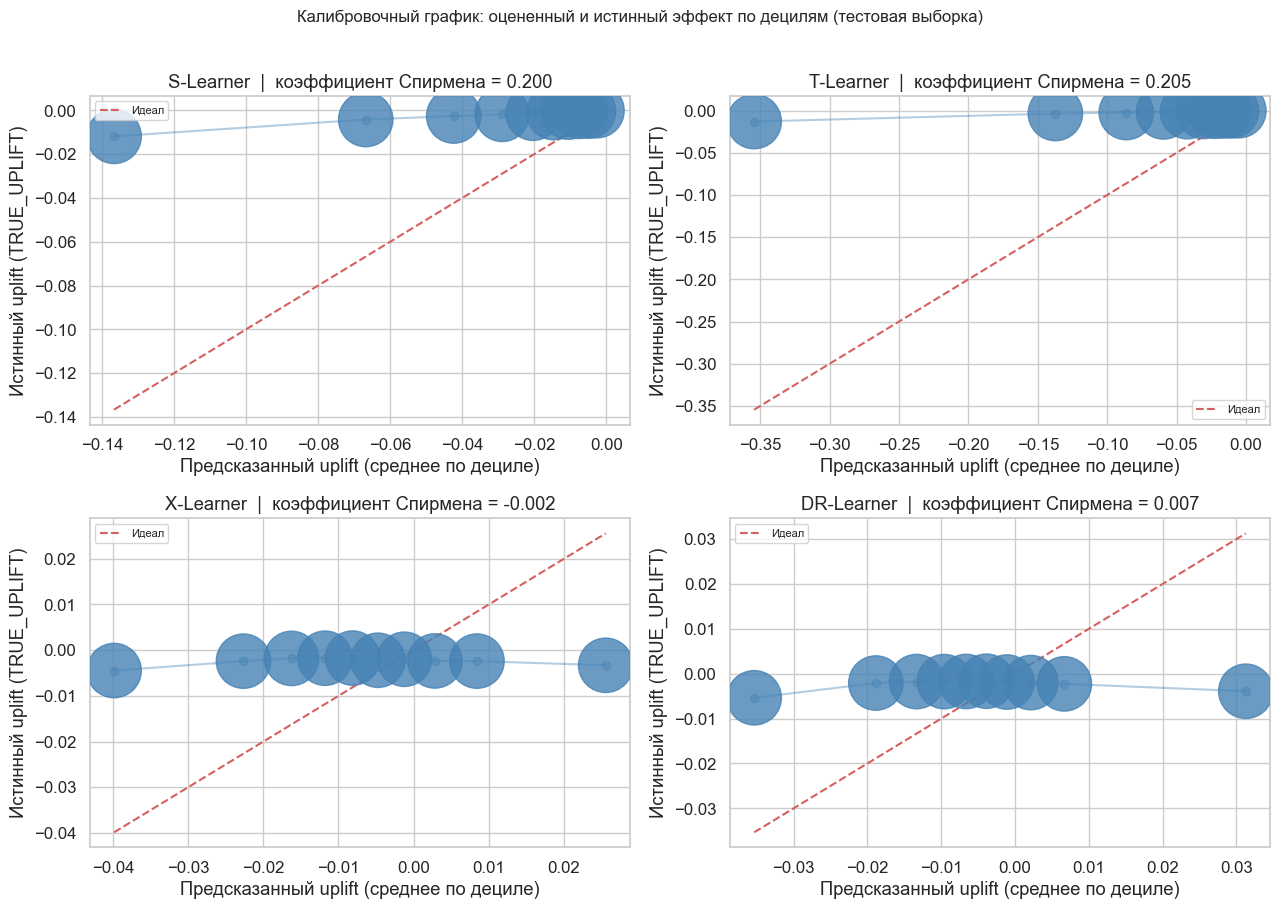

Как читать: точки на красной диагонали = идеальная калибровка.
Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.


In [72]:
# Калибровочный график: оцененный и истинный эффект по децилям
uplift_models_cal = {k: v for k, v in model_uplift_preds.items()
                      if k != 'Риск-ориентированный (BASE_PD)'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, uplift_models_cal.items()):
    df_cal = pd.DataFrame({'pred': pred, 'true': true_uplift})
    df_cal['decile'] = pd.qcut(df_cal['pred'], q=10, labels=False, duplicates='drop')
    cal = df_cal.groupby('decile').agg(
        pred_mean=('pred', 'mean'),
        true_mean=('true', 'mean'),
        count=('pred', 'count'),
    ).reset_index()

    ax.scatter(cal['pred_mean'], cal['true_mean'],
               s=cal['count'] / 4, alpha=0.8, color='steelblue', zorder=5)
    ax.plot(cal['pred_mean'], cal['true_mean'], '-o', color='steelblue', alpha=0.4)

    lo = min(cal['pred_mean'].min(), cal['true_mean'].min())
    hi = max(cal['pred_mean'].max(), cal['true_mean'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', label='Идеал')

    sp_rho, _ = stats.spearmanr(pred, true_uplift)
    ax.set_title(f'{name}  |  коэффициент Спирмена = {sp_rho:.3f}')
    ax.set_xlabel('Предсказанный uplift (среднее по дециле)')
    ax.set_ylabel('Истинный uplift (TRUE_UPLIFT)')
    ax.legend(fontsize=8)

plt.suptitle('Калибровочный график: оцененный и истинный эффект по децилям (тестовая выборка)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Как читать: точки на красной диагонали = идеальная калибровка.')
print('Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.')


<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по ground truth-калибровке.</b>

График показывает, что S-Learner и T-Learner частично восстанавливают порядок клиентов по истинному эффекту коммуникации: при переходе между децилями меняется средний `TRUE_UPLIFT`, то есть модельный скор связан с реальной полезностью воздействия. Это согласуется с положительным коэффициентом Спирмена и подтверждает, что высокий AUUC у этих моделей не является только артефактом policy-метрики.

При этом зависимость не идеальная: средний истинный эффект по децилям меняется не строго монотонно. Значит, модели улавливают общий uplift-сигнал, но не восстанавливают индивидуальный эффект безошибочно. Поэтому их корректнее использовать для ранжирования и выбора приоритетных сегментов, а не для буквальной интерпретации точного эффекта каждого клиента.

Для X-Learner и DR-Learner выраженного градиента по децилям не видно: средний `TRUE_UPLIFT` меняется слабо или нестабильно. Это подтверждает предыдущий вывод: в текущей постановке эти методы не смогли надежно восстановить структуру истинного эффекта, несмотря на более сложную causal-архитектуру.

<b>Итог.</b> Децильная проверка по `TRUE_UPLIFT` поддерживает выбор S-Learner и особенно T-Learner как содержательных uplift-моделей, а слабые результаты X-Learner и DR-Learner подтверждаются не только AUUC, но и сравнением с ground truth.

</div>

<h2 id="uplift-save-scores">Сохранение скорингов моделей</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем сохраняем результаты моделей.</b> После обучения и проверки uplift-моделей нужно зафиксировать их скоринги в отдельный файл. Это позволяет использовать результаты дальше без повторного обучения моделей: для анализа бизнес-политик, построения графиков, сравнения стратегий и проверки устойчивости выводов.

<p><b>Что сохраняется.</b></p>

В таблицу `uplift_scores.csv` попадают test- и OOT-наблюдения, для которых уже рассчитаны основные risk- и uplift-оценки:

<ul>
  <li>служебные поля: `split`, фактический outcome `y`, бинарный treatment-флаг, канал `COMMUNICATION`;</li>
  <li>синтетические диагностические поля: `BASE_PD`, `TRUE_UPLIFT`, `RISK_SEGMENT`;</li>
  <li>скоры risk-based моделей: CatBoost и LogReg;</li>
  <li>итоговые скоры uplift-моделей: S-Learner, T-Learner, X-Learner, DR-Learner;</li>
  <li>поканальные uplift-оценки для S-Learner и T-Learner.</li>
</ul>

<p><b>Как читать эти поля.</b></p>

`score_s`, `score_t`, `score_x` и `score_dr` используются как приоритет для коммуникации: чем выше score, тем сильнее ожидаемое снижение вероятности дефолта. Поканальные поля `uplift_*` хранят именно оценку изменения PD по конкретному каналу: отрицательное значение означает, что канал снижает вероятность дефолта, положительное — что контакт может быть бесполезным или вредным.

<p><b>Зачем включаем `TRUE_UPLIFT`.</b></p>

`TRUE_UPLIFT` сохраняется только как диагностическое поле синтетического стенда. Оно не используется для обучения моделей, но нужно для последующих проверок качества: сравнения с ground truth, анализа сегментов и контроля того, насколько модельное ранжирование связано с истинным эффектом.

</div>

In [73]:
scores_to_save = pd.DataFrame({
    'split':          ['test'] * len(y_test) + ['oot'] * len(y_oot),
    'y':              np.concatenate([y_test, y_oot]),
    'treatment_bin':  np.concatenate([t_test_bin, t_oot_bin]),
    'COMMUNICATION':  np.concatenate([T_test, T_oot]),
    'BASE_PD':        np.concatenate([test['BASE_PD'].values,  oot['BASE_PD'].values]),
    'TRUE_UPLIFT':    np.concatenate([test['TRUE_UPLIFT'].values, oot['TRUE_UPLIFT'].values]),
    'RISK_SEGMENT':   np.concatenate([test['RISK_SEGMENT'].values, oot['RISK_SEGMENT'].values]),
    # Оценки риск-ориентированных базовых моделей
    'score_cb_saved': np.concatenate([cb_saved_score_test, cb_saved_score_oot]),
    'score_cb_all':   np.concatenate([cb_all_score_test,   cb_all_score_oot]),
    'score_lr_saved': np.concatenate([lr_saved_score_test, lr_saved_score_oot]),
    'score_lr_all':   np.concatenate([lr_all_score_test,   lr_all_score_oot]),
    # Оценки моделей индивидуального эффекта воздействия
    'score_s':        np.concatenate([score_s_test,  score_s_oot]),
    'score_t':        np.concatenate([score_t_test,  score_t_oot]),
    'score_x':        np.concatenate([score_x_test,  score_x_oot]),
    'score_dr':       np.concatenate([score_dr_test, score_dr_oot]),
    # Per-channel S-Learner
    'uplift_s_sms':      np.concatenate([uplift_s_test['sms'],          uplift_s_oot['sms']]),
    'uplift_s_robot':    np.concatenate([uplift_s_test['robot_call'],   uplift_s_oot['robot_call']]),
    'uplift_s_operator': np.concatenate([uplift_s_test['operator_call'],uplift_s_oot['operator_call']]),
    # Per-channel T-Learner
    'uplift_t_sms':      np.concatenate([uplift_t_test['sms'],          uplift_t_oot['sms']]),
    'uplift_t_robot':    np.concatenate([uplift_t_test['robot_call'],   uplift_t_oot['robot_call']]),
    'uplift_t_operator': np.concatenate([uplift_t_test['operator_call'],uplift_t_oot['operator_call']]),
})
scores_to_save.to_csv('data/processed/uplift_scores.csv', index=False)
print(f"Оценки моделей сохранены: {len(scores_to_save):,} строк × {len(scores_to_save.columns)} столбцов")

Оценки моделей сохранены: 123,005 строк × 21 столбцов


<h2 id="uplift-learning-curve">Зависимость качества от объема обучающей выборки</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужен этот раздел.</b> До этого модели оценивались на полном объеме обучающих данных. Но для реального внедрения важно понять, сколько исторических наблюдений нужно, чтобы uplift-модель стала стабильной и полезной. Особенно это важно для банковских коммуникаций: новые каналы, новые продукты и новые политики часто стартуют с ограниченной истории.

<p><b>Что проверяет learning curve.</b></p>

Дальше модели обучаются на разных долях обучающей выборки: от очень малых подвыборок до 100% данных. Для каждой доли заново считаются AUUC и связь с `TRUE_UPLIFT`. Это позволяет увидеть, как качество меняется при росте количества зрелых наблюдений.

<p><b>Почему для uplift это важнее, чем для обычного risk-score.</b></p>

Risk-модель учится предсказывать один outcome на всей выборке. Uplift-модель должна сравнивать outcome между группами воздействия и контроля, а в multi-treatment постановке еще и различать несколько каналов коммуникации. Поэтому ей нужен не только большой общий объем данных, но и достаточное число наблюдений в каждом канале.

<p><b>Какие модели сравниваются.</b></p>

В этом разделе сравниваются практические risk-based модели и основные uplift-подходы: S-Learner, T-Learner и DR-Learner. Для T-Learner особенно важен баланс каналов, потому что он обучает отдельные модели для control-группы и каждого канала коммуникации. Если редких каналов мало, T-Learner может быть недоступен или нестабилен на малых выборках.

<p><b>Как читать результаты.</b></p>

Если модель быстро выходит на плато AUUC, значит ей достаточно умеренного объема данных для устойчивого ранжирования. Если качество сильно скачет или становится доступным только на больших долях выборки, значит метод чувствителен к объему данных и требует более зрелой истории коммуникаций.

</div>

In [74]:
fractions_lc = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7, 1.0]
MIN_CH_SAMPLES = 150
lc_rows = []

print(f'{"frac":>5} {"N":>7} | {"CB-risk":>8} {"LR-risk":>8} {"S-Lrn":>8} {"T-Lrn":>8} {"DR-Lrn":>8}')
print('-' * 65)

for frac in fractions_lc:
    if frac < 1.0:
        from sklearn.model_selection import train_test_split as _tts
        idx_f, _ = _tts(np.arange(len(X_train)), train_size=frac,
                         stratify=t_train_bin, random_state=RANDOM_SEED)
        idx_f = sorted(idx_f)
    else:
        idx_f = np.arange(len(X_train))

    Xf      = X_train.iloc[idx_f].reset_index(drop=True)
    yf      = y_train[idx_f]
    Tf      = T_train[idx_f]
    tf_bin  = t_train_bin[idx_f]
    y_orig_f = train.iloc[idx_f]['TARGET'].values
    row = {'frac': frac, 'n': len(idx_f)}

    # ── CatBoost-risk (все feat + categoricals) ────────────────────────────
    Xf_cba = pd.concat([
        Xf,
        train.iloc[idx_f][cat_cols_all].fillna('missing').astype(str).reset_index(drop=True)
    ], axis=1)
    cb_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                                cat_features=cat_idx_all,
                                random_seed=RANDOM_SEED, verbose=0)
    cb_lc.fit(Xf_cba, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, cb_lc.predict_proba(X_test_cba)[:, 1])
    rho, _ = stats.spearmanr(cb_lc.predict_proba(X_test_cba)[:, 1], true_uplift_test)
    row['CatBoost-risk AUUC'] = auuc;  row['CatBoost-risk rho'] = rho

    # ── LogReg-risk (все числовые feat) ────────────────────────────────────
    lr_lc = Pipeline([('scaler', StandardScaler()),
                       ('lr', LogisticRegression(C=0.1, max_iter=500,
                                                  random_state=RANDOM_SEED))])
    lr_lc.fit(Xf, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, lr_lc.predict_proba(X_test)[:, 1])
    rho, _ = stats.spearmanr(lr_lc.predict_proba(X_test)[:, 1], true_uplift_test)
    row['LogReg-risk AUUC'] = auuc;  row['LogReg-risk rho'] = rho

    # ── S-Learner ─────────────────────────────────────────────────────────
    enc_lc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc_lc.fit(Tf.reshape(-1, 1))
    Xf_s = add_treatment_ohe(Xf, Tf, enc_lc)
    s_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
    s_lc.fit(Xf_s, yf)
    upl_s_lc = s_learner_uplift_per_channel(s_lc, X_test, enc_lc, channels_list)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_s_lc['best'])
    rho, _ = stats.spearmanr(upl_s_lc['best'], true_uplift_test)
    row['S-Learner AUUC'] = auuc;  row['S-Learner rho'] = rho

    # ── T-Learner ─────────────────────────────────────────────────────────
    t_lc = {}; ok = True
    for ch in ['control'] + channels_list:
        mask_ch = Tf == ch
        if mask_ch.sum() < MIN_CH_SAMPLES:
            ok = False; break
        m = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
        m.fit(Xf[mask_ch].reset_index(drop=True), yf[mask_ch])
        t_lc[ch] = m
    if ok:
        upl_t_lc = t_learner_uplift(t_lc, X_test, channels_list)
        _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_t_lc['best'])
        rho, _ = stats.spearmanr(upl_t_lc['best'], true_uplift_test)
        row['T-Learner AUUC'] = auuc;  row['T-Learner rho'] = rho
    else:
        row['T-Learner AUUC'] = float('nan');  row['T-Learner rho'] = float('nan')

    # ── DR-Learner (упрощённый: 3-fold, 100 iter nuisance) ────────────────
    kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    Xf_arr = Xf.values
    mu1_o = np.zeros(len(Xf_arr)); mu0_o = np.zeros(len(Xf_arr)); e_o = np.zeros(len(Xf_arr))
    for _, (idx_tr, idx_val) in enumerate(kf3.split(Xf_arr)):
        Xk, Xv = Xf_arr[idx_tr], Xf_arr[idx_val]
        yk, tk = yf[idx_tr], tf_bin[idx_tr]
        mu_k = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                   random_seed=RANDOM_SEED, verbose=0)
        mu_k.fit(np.column_stack([Xk, tk]), yk)
        mu1_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.ones(len(Xv))]))[:, 1]
        mu0_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.zeros(len(Xv))]))[:, 1]
        e_k = CatBoostClassifier(iterations=50, learning_rate=0.05, depth=3,
                                  random_seed=RANDOM_SEED, verbose=0)
        e_k.fit(Xk, tk)
        e_o[idx_val] = e_k.predict_proba(Xv)[:, 1]
    e_cl = np.clip(e_o, 0.05, 0.95)
    dr_ps = (mu1_o - mu0_o) + (tf_bin - e_cl) / (e_cl * (1 - e_cl)) * (yf - (tf_bin * mu1_o + (1 - tf_bin) * mu0_o))
    dr_lc = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5,
                               random_seed=RANDOM_SEED, verbose=0)
    dr_lc.fit(Xf_arr, dr_ps)
    upl_dr_lc = dr_lc.predict(X_test.values)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_dr_lc)
    rho, _ = stats.spearmanr(upl_dr_lc, true_uplift_test)
    row['DR-Learner AUUC'] = auuc;  row['DR-Learner rho'] = rho

    lc_rows.append(row)
    print(f"{frac:5.0%} {len(idx_f):>7,} | "
          f"{row['CatBoost-risk AUUC']:>8.1f} "
          f"{row['LogReg-risk AUUC']:>8.1f} "
          f"{row.get('S-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('T-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('DR-Learner AUUC', float('nan')):>8.1f}")

lc_df = pd.DataFrame(lc_rows).set_index('n')
print('\nГотово.')

 frac       N |  CB-risk  LR-risk    S-Lrn    T-Lrn   DR-Lrn
-----------------------------------------------------------------
   0%     922 |    187.0     21.1    135.2      nan    -65.1
   1%   1,845 |    180.0     47.1    -32.5      nan    -77.2
   2%   3,690 |    183.0     70.3    260.1      nan    -21.8
   5%   9,225 |    210.3    103.0    338.5    353.3     30.3
  10%  18,450 |    221.4    126.7    328.9    356.3      0.7
  20%  36,901 |    228.6    150.2    332.4    357.4    -42.7
  35%  64,577 |    237.2    158.8    334.1    358.7    -30.0
  50%  92,253 |    234.8    171.4    335.0    359.6    -45.6
  70% 129,154 |    237.8    174.7    338.1    358.9    -41.7
 100% 184,506 |    240.5    179.1    336.7    360.4    -69.1

Готово.


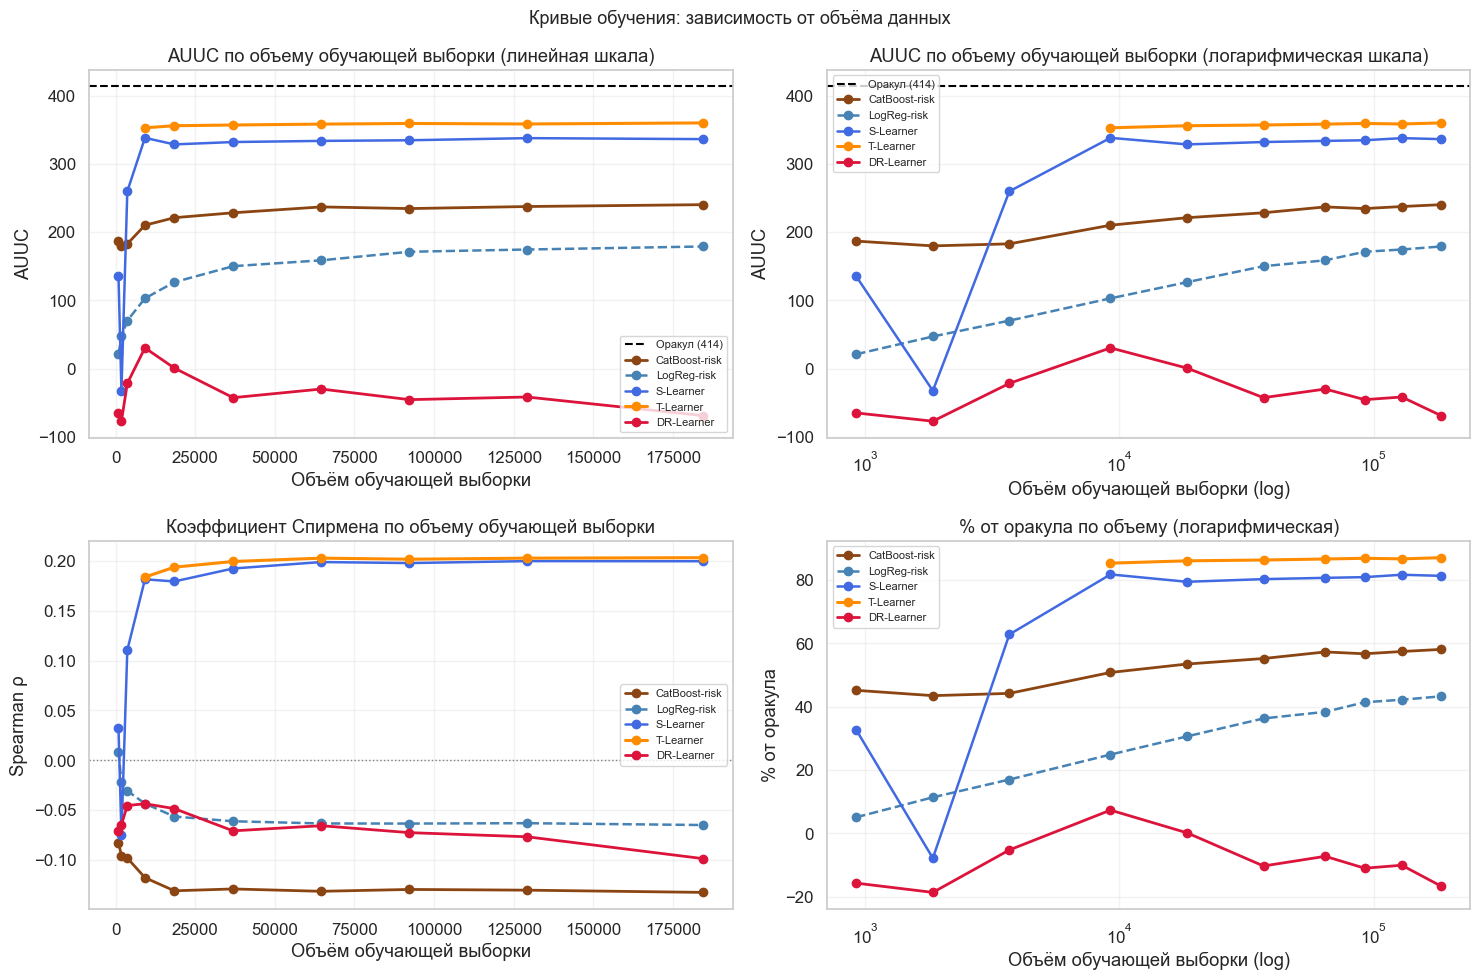


Итоговые значения при 100% обучающей выборки:
Модель                        AUUC % от оракула коэффициент Спирмена
--------------------------------------------------------------
CatBoost-risk                240.5       58.1%        -0.1323
LogReg-risk                  179.1       43.3%        -0.0648
S-Learner                    336.7       81.3%         0.1996
T-Learner                    360.4       87.1%         0.2032
DR-Learner                   -69.1      -16.7%        -0.0985


In [75]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

_styles = {
    'CatBoost-risk': ('saddlebrown', '-',  2.0),
    'LogReg-risk':   ('steelblue',   '--', 1.8),
    'S-Learner':     ('royalblue',   '-',  1.8),
    'T-Learner':     ('darkorange',  '-',  2.2),
    'DR-Learner':    ('crimson',     '-',  2.0),
}
oracle_auuc_lc = baseline_auuc['Logged-policy oracle']

for ax_idx, (ax, ylabel, col_suffix, title, log_x) in enumerate([
    (axes[0,0], 'AUUC',        'AUUC', 'AUUC по объему обучающей выборки (линейная шкала)',     False),
    (axes[0,1], 'AUUC',        'AUUC', 'AUUC по объему обучающей выборки (логарифмическая шкала)',     True),
    (axes[1,0], 'Spearman ρ',  'rho',  'Коэффициент Спирмена по объему обучающей выборки',                False),
    (axes[1,1], '% от оракула', 'AUUC', '% от оракула по объему (логарифмическая)', True),
]):
    if col_suffix == 'AUUC' and ylabel == 'AUUC':
        ax.axhline(oracle_auuc_lc, color='black', ls='--', lw=1.5,
                   label=f'Оракул ({oracle_auuc_lc:.0f})')
    if col_suffix == 'rho':
        ax.axhline(0, color='gray', ls=':', lw=1)

    for model, (color, ls, lw) in _styles.items():
        col = f'{model} {col_suffix}'
        if col not in lc_df.columns:
            continue
        vals = lc_df[col]
        if ylabel == '% от оракула':
            vals = vals / oracle_auuc_lc * 100
        ax.plot(lc_df.index, vals, f'o{ls}', color=color, lw=lw, label=model)

    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel('Объём обучающей выборки' + (' (log)' if log_x else ''))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Кривые обучения: зависимость от объёма данных', fontsize=13)
plt.tight_layout()
plt.show()

# Итоговая таблица
print('\nИтоговые значения при 100% обучающей выборки:')
full_row = lc_df.iloc[-1]
print(f'{"Модель":<25} {"AUUC":>8} {"% от оракула":>12} {"коэффициент Спирмена":>14}')
print('-' * 62)
for model in _styles:
    auuc_v = full_row.get(f'{model} AUUC', float('nan'))
    rho_v  = full_row.get(f'{model} rho', float('nan'))
    pct    = auuc_v / oracle_auuc_lc * 100 if not pd.isna(auuc_v) else float('nan')
    print(f'{model:<25} {auuc_v:>8.1f} {pct:>10.1f}% {rho_v:>14.4f}')

<h3 id="uplift-learning-summary">Выводы по зависимости качества от объема данных</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по learning curve.</b>

<p><b>1. Uplift-моделям нужен достаточный объем зрелых коммуникационных данных.</b></p>

На малых долях обучающей выборки результаты нестабильны. Это особенно заметно для uplift-подходов: они должны не просто предсказывать дефолт, а сравнивать исходы между contacted- и control-группами. При малом числе наблюдений в каналах оценка эффекта становится шумной.

<p><b>2. S-Learner быстрее выходит на рабочий уровень.</b></p>

S-Learner использует одну общую модель и обучается на всей выборке сразу, поэтому он может давать осмысленный результат раньше, чем более требовательные методы. Уже при умеренном объеме данных его AUUC становится близким к итоговому уровню, а при 100% выборки достигает примерно 336.7, или 81.3% от oracle.

Практически это означает, что S-Learner может быть хорошей стартовой моделью, когда данных по отдельным каналам еще мало, но уже хочется получить uplift-ранжирование.

<p><b>3. T-Learner становится сильнее, когда хватает данных по каналам.</b></p>

T-Learner обучает отдельные модели для control-группы и каждого канала коммуникации. Поэтому при очень малых выборках он может быть недоступен или нестабилен: редкие каналы не дают достаточного числа наблюдений. В эксперименте T-Learner начинает считаться только после накопления минимального объема данных по каждому каналу.

Когда данных становится достаточно, T-Learner выходит на лучший уровень среди обученных uplift-моделей: при 100% выборки AUUC около 360.4, или 87.1% от oracle. Это подтверждает его преимущество, но только при условии зрелой истории коммуникаций.

<p><b>4. Risk-based модели растут более плавно, но остаются ниже uplift-подходов.</b></p>

CatBoost-risk и LogReg-risk улучшаются по мере роста обучающей выборки, однако их итоговый уровень ниже S- и T-Learner: CatBoost-risk достигает около 240.5 AUUC, LogReg-risk — около 179.1. Это показывает, что обычный риск-скоринг извлекает полезный сигнал, но не заменяет моделирование эффекта воздействия.

<p><b>5. DR-Learner остается нестабильным.</b></p>

DR-Learner не показывает устойчивого улучшения при росте выборки и в итоговой точке остается слабым. Это согласуется с предыдущими результатами: в текущей постановке DR-псевдоисходы слишком шумные, а увеличение объема данных само по себе не решает проблему слабого overlap и высокой дисперсии IPW-компоненты.

<p><b>6. Практический вывод.</b></p>

Learning curve показывает компромисс между устойчивостью и гибкостью:

<ul>
  <li><b>S-Learner</b> проще и стабильнее на меньших объемах данных;</li>
  <li><b>T-Learner</b> дает лучший результат, но требует достаточного числа наблюдений в каждом канале;</li>
  <li><b>risk-based модели</b> можно использовать как ранний baseline, но они не раскрывают весь uplift-потенциал;</li>
  <li><b>DR-Learner</b> в этой конфигурации не является надежным вариантом.</li>
</ul>

<b>Итог.</b> Для практического внедрения uplift-подхода важно накапливать не просто больше данных, а больше сбалансированных данных по каждому каналу коммуникации. Без этого более гибкие методы могут быть нестабильны, даже если общий размер выборки выглядит большим.

</div>

<h2 id="uplift-scenarios">Проверка при разных сценариях связи риска и эффекта</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужен этот стресс-тест.</b> В основном эксперименте базовый риск клиента и эффект коммуникации частично связаны. Это реалистично для кредитной задачи: более рискованные клиенты могут чаще попадать в сегмент, где коммуникация действительно влияет на поведение. Но такая связь дает risk-based стратегиям структурное преимущество. Поэтому важно проверить, сохраняется ли ценность uplift-подхода, если связь между риском и эффектом изменить.

<p><b>Главный вопрос раздела.</b></p>

Мы проверяем, зависит ли вывод о пользе uplift-моделей от конкретного механизма генерации данных. Если risk-based модели конкурентны только тогда, когда эффект почти совпадает с риском, это означает, что высокий AUUC risk-score не доказывает causal-качество. Если uplift-модели сохраняют качество в разных сценариях, это усиливает аргумент в пользу моделирования индивидуального эффекта.

<p><b>Что меняется в сценариях.</b></p>

Во всех сценариях сохраняются одни и те же клиенты, признаки, train/test/OOT-разбиение и историческая политика коммуникаций. Меняется только связь между `BASE_PD` и `TRUE_UPLIFT`, то есть то, у каких клиентов коммуникация дает наибольшее снижение вероятности дефолта. Благодаря этому сценарии сравнивают не разные датасеты, а разные предположения о механизме эффекта.

<p><b>Какие сценарии рассматриваются.</b></p>

<table>
  <thead>
    <tr>
      <th>Сценарий</th>
      <th>Смысл</th>
      <th>Что проверяем</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>aligned</code></td>
      <td>Риск и эффект согласованы</td>
      <td>Может ли risk-based стратегия быть конкурентной, когда высокий риск действительно связан с полезностью коммуникации</td>
    </tr>
    <tr>
      <td><code>weakly_aligned</code></td>
      <td>Связь частично ослаблена</td>
      <td>Насколько устойчивы выводы, если эффект уже не так жестко следует за риском</td>
    </tr>
    <tr>
      <td><code>orthogonal</code></td>
      <td>Эффект слабее связан с риском</td>
      <td>Теряет ли risk-score причинный смысл, когда риск хуже объясняет полезность коммуникации</td>
    </tr>
    <tr>
      <td><code>mid_risk</code></td>
      <td>Максимальный эффект у клиентов среднего риска</td>
      <td>Способна ли uplift-модель найти изменяемый сегмент, который не лежит на вершине риск-рейтинга</td>
    </tr>
  </tbody>
</table>

<p><b>Как читать результаты.</b></p>

Если risk-based стратегия остается сильной во всех сценариях, значит риск сам по себе хорошо приближает эффект коммуникации. Если же ее преимущество зависит от сценария, а uplift-модели лучше адаптируются к изменению структуры эффекта, это показывает практический смысл uplift-подхода: он нужен не для замены кредитного скоринга, а для поиска клиентов, у которых контакт действительно меняет outcome.

<b>Главный акцент.</b> Этот раздел проверяет границы применимости вывода: где достаточно обычного риск-скоринга, а где требуется отдельное моделирование индивидуального эффекта коммуникации.

</div>

In [76]:
# ====== Common Random Numbers — единый вектор для всех сценариев ======
_rng_crn = np.random.RandomState(RANDOM_SEED + 200)
_u_train  = _rng_crn.uniform(size=len(train))
_u_test   = _rng_crn.uniform(size=len(test))

# ====== Scenario generators (работают со split-датафреймом) ======

def _sw_aligned(df, **kw):
    """Текущий DGP: TRUE_UPLIFT без изменений."""
    return df['TRUE_UPLIFT'].values.copy()


def _sw_weakly(df, alpha=0.5, seed=RANDOM_SEED + 201, **kw):
    """50% исходного + 50% перемешанного внутри канала."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        n_ch  = mask.sum()
        perm  = rng_s.permutation(n_ch)
        idx   = np.where(mask)[0]
        tu[idx] = alpha * tu[idx] + (1 - alpha) * tu[idx][perm]
    return tu


def _sw_orthogonal(df, seed=RANDOM_SEED + 202, **kw):
    """Полное перемешивание TRUE_UPLIFT внутри каждого канала."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        idx       = np.where(mask)[0]
        perm      = rng_s.permutation(len(idx))
        tu[idx]   = tu[idx][perm]
    return tu


def _sw_mid_risk(df, seed=RANDOM_SEED + 203, **kw):
    """Сильнейшие эффекты — клиентам ближайшим к медиане BASE_PD канала."""
    tu  = df['TRUE_UPLIFT'].values.copy()
    bp  = df['BASE_PD'].values
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 10:
            continue
        idx      = np.where(mask)[0]
        eff_ch   = tu[idx]
        bp_ch    = bp[idx]

        # Сортируем эффекты по убыванию силы (самые отрицательные — первые)
        eff_order  = np.argsort(eff_ch)          # ascending: [0] = самый отрицательный

        # Сортируем клиентов: ближайшие к медиане BASE_PD канала — первые
        bp_med     = np.median(bp_ch)
        dist       = np.abs(bp_ch - bp_med)
        client_order = np.argsort(dist)          # [0] = ближе всего к медиане

        # Присваиваем: клиент с позиции i в client_order получает эффект с позиции i в eff_order
        new_eff              = np.empty(len(idx))
        new_eff[client_order] = eff_ch[eff_order]
        tu[idx]               = new_eff
    return tu


_scenarios = {
    'aligned':        _sw_aligned,
    'weakly_aligned': _sw_weakly,
    'orthogonal':     _sw_orthogonal,
    'mid_risk':       _sw_mid_risk,
}

print('Сценарии проверки связи риска и эффекта:', list(_scenarios.keys()))
print(f'Единые случайные числа: размер обучающего вектора={_u_train.shape}, размер тестового вектора={_u_test.shape}')

Сценарии проверки связи риска и эффекта: ['aligned', 'weakly_aligned', 'orthogonal', 'mid_risk']
Единые случайные числа: размер обучающего вектора=(184506,), размер тестового вектора=(61502,)


<h3 id="uplift-scenario-visual">Визуальная проверка сценариев</h3>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем смотрим графики перед обучением.</b> Перед сравнением моделей важно визуально проверить, какой именно механизм эффекта заложен в каждом сценарии. Иначе результаты AUUC будет трудно интерпретировать: модель может выигрывать не потому, что хорошо оценивает uplift, а потому что сценарий делает риск почти готовым proxy для полезности коммуникации.

<p><b>Как читать графики.</b></p>

На каждом графике по оси X отложена базовая вероятность дефолта `BASE_PD`, а по оси Y — полезность коммуникации `-TRUE_UPLIFT`. Чем выше значение по оси Y, тем сильнее коммуникация снижает вероятность дефолта. Точки показывают отдельных клиентов, а красная линия — среднюю полезность коммуникации по децилям риска.

<p><b>Что означает форма зависимости.</b></p>

Если красная линия растет вместе с `BASE_PD`, значит более рискованные клиенты в среднем сильнее выигрывают от коммуникации. В таком сценарии risk-based стратегия получает структурное преимущество: даже обычный риск-скор может хорошо ранжировать клиентов для контакта.

Если линия становится более плоской, связь риска и эффекта ослабевает. Тогда высокий риск хуже объясняет, кому коммуникация действительно поможет, и возрастает роль uplift-модели.

Если максимум полезности находится не в правой части графика, а ближе к середине шкалы риска, то простая стратегия «контактировать самых рискованных» становится менее обоснованной. В этом случае полезный сегмент может находиться среди клиентов среднего риска, и его нужно искать отдельно.

<p><b>Что проверяем дальше.</b></p>

Эти графики задают контекст для последующего сценарного сравнения: мы смотрим, как меняется качество risk-based и uplift-стратегий, когда связь между риском и полезностью коммуникации становится сильной, слабой или смещается к среднему риску.

</div>

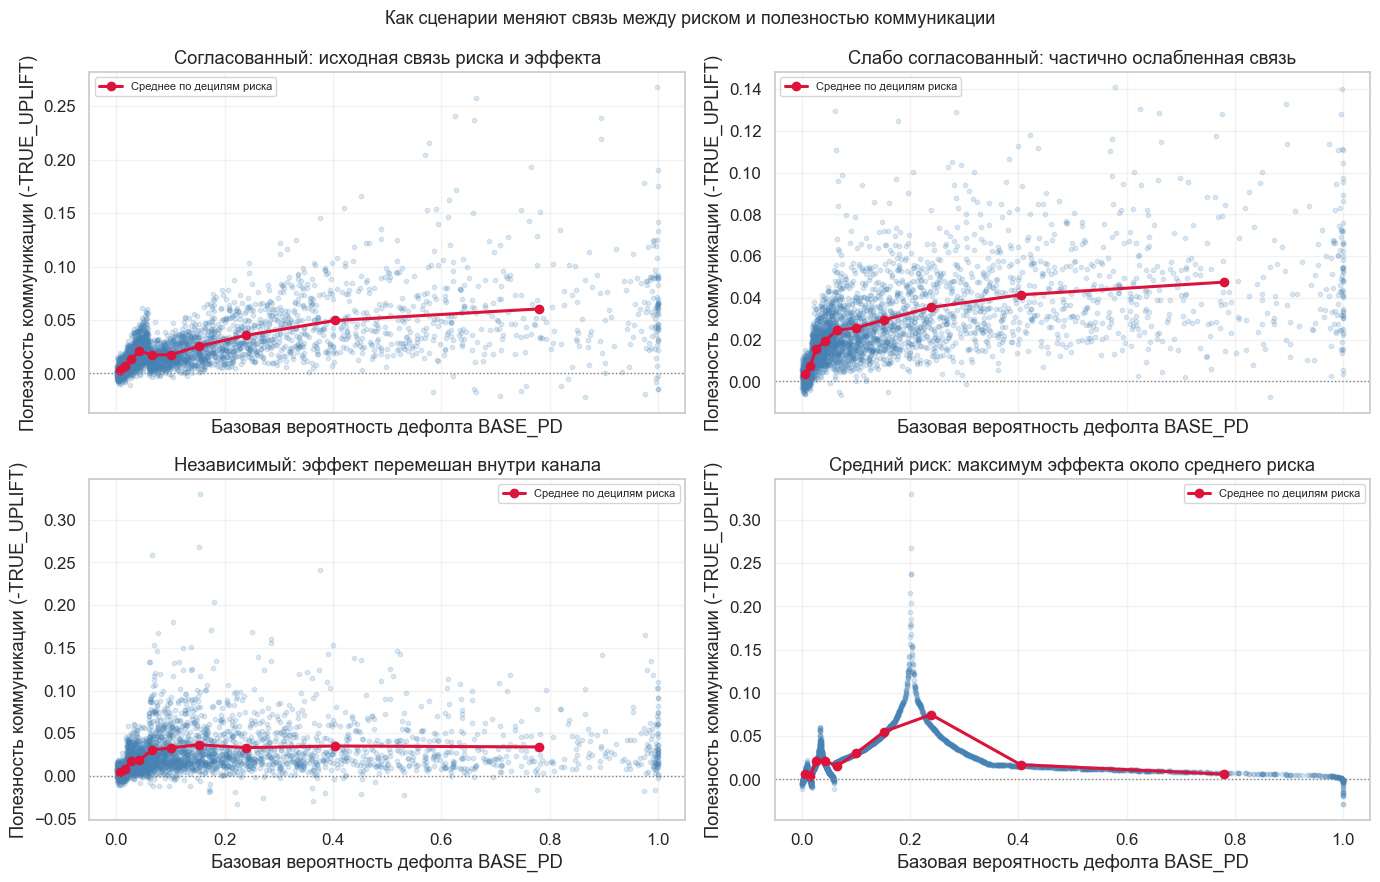

,Сценарий,Описание,"Spearman(BASE_PD, -TRUE_UPLIFT)",Средняя полезность
0,Согласованный,исходная связь риска и эффекта,0.7110,0.0250
1,Слабо согласованный,частично ослабленная связь,0.7352,0.0250
2,Независимый,эффект перемешан внутри канала,0.5036,0.0250
3,Средний риск,максимум эффекта около среднего риска,0.3351,0.0250


In [77]:
_scenario_labels = {
    'aligned': 'Согласованный',
    'weakly_aligned': 'Слабо согласованный',
    'orthogonal': 'Независимый',
    'mid_risk': 'Средний риск',
}

_scenario_explain = {
    'aligned': 'исходная связь риска и эффекта',
    'weakly_aligned': 'частично ослабленная связь',
    'orthogonal': 'эффект перемешан внутри канала',
    'mid_risk': 'максимум эффекта около среднего риска',
}

_active_mask = test['COMMUNICATION'] != 'control'
_plot_base = test.loc[_active_mask, ['BASE_PD', 'COMMUNICATION']].copy()
_scenario_diag = []

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (_sc_name, _gen_fn) in zip(axes, _scenarios.items()):
    _effect = _gen_fn(test)[_active_mask.values]
    _benefit = -_effect
    _df_plot = _plot_base.copy()
    _df_plot['benefit'] = _benefit
    _df_plot['risk_bin'] = pd.qcut(_df_plot['BASE_PD'], q=10, duplicates='drop')
    _line = _df_plot.groupby('risk_bin', observed=True).agg(
        base_pd=('BASE_PD', 'mean'),
        benefit=('benefit', 'mean'),
    )

    _rho, _p = stats.spearmanr(_df_plot['BASE_PD'], _df_plot['benefit'])
    _scenario_diag.append({
        'Сценарий': _scenario_labels[_sc_name],
        'Описание': _scenario_explain[_sc_name],
        'Spearman(BASE_PD, -TRUE_UPLIFT)': _rho,
        'Средняя полезность': _df_plot['benefit'].mean(),
    })

    _sample = _df_plot.sample(min(3500, len(_df_plot)), random_state=RANDOM_SEED)
    ax.scatter(_sample['BASE_PD'], _sample['benefit'], s=10, alpha=0.18, color='steelblue')
    ax.plot(_line['base_pd'], _line['benefit'], color='crimson', linewidth=2.2, marker='o',
            label='Среднее по децилям риска')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f"{_scenario_labels[_sc_name]}: {_scenario_explain[_sc_name]}")
    ax.set_xlabel('Базовая вероятность дефолта BASE_PD')
    ax.set_ylabel('Полезность коммуникации (-TRUE_UPLIFT)')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle('Как сценарии меняют связь между риском и полезностью коммуникации', fontsize=13)
plt.tight_layout()
plt.show()

_scenario_diag_df = pd.DataFrame(_scenario_diag)
display(_scenario_diag_df.round({
    'Spearman(BASE_PD, -TRUE_UPLIFT)': 4,
    'Средняя полезность': 5,
}))

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по визуальной проверке сценариев.</b>

<p><b>1. Сценарии действительно меняют связь риска и полезности коммуникации.</b></p>

Графики показывают, что сценарии отличаются не средним уровнем эффекта, а именно формой связи между `BASE_PD` и `-TRUE_UPLIFT`. Средняя полезность коммуникации остается примерно одинаковой во всех сценариях — около 0.025, но распределяется между клиентами по-разному. Это важно: дальше модели сравниваются при сопоставимом общем потенциале, но при разной структуре эффекта.

<p><b>2. В `aligned` риск получает естественное преимущество.</b></p>

В согласованном сценарии красная линия средних значений растет вместе с `BASE_PD`: чем выше базовый риск, тем выше средняя полезность коммуникации. Коэффициент Спирмена между `BASE_PD` и `-TRUE_UPLIFT` равен 0.7110. В такой постановке risk-based отбор должен быть конкурентным, потому что сам риск уже близок к proxy для эффекта воздействия.

<p><b>3. В `weakly_aligned` связь остается заметной.</b></p>

Слабо согласованный сценарий формально ослабляет связь риска и эффекта, но зависимость все еще остается выраженной: Spearman равен 0.7352. Поэтому здесь risk-based стратегии тоже могут сохранять сильные позиции. Этот сценарий показывает, что даже частичное перемешивание эффекта не обязательно полностью разрушает преимущество риска, если историческая структура данных все еще сохраняет связь между risk и uplift.

<p><b>4. В `orthogonal` и `mid_risk` риск становится менее надежным ориентиром.</b></p>

В сценарии `orthogonal` эффект перемешивается внутри каналов, поэтому связь с `BASE_PD` ослабевает: Spearman снижается до 0.5036. В `mid_risk` максимум полезности смещается к клиентам среднего риска, и связь становится еще слабее: Spearman равен 0.3351. В этих условиях стратегия «контактировать самых рискованных» становится менее очевидной, потому что наиболее изменяемые клиенты уже не обязательно находятся на вершине risk-рейтинга.

<p><b>5. Что это дает для дальнейшего сравнения моделей.</b></p>

Визуальная диагностика показывает, что сценарии создают разные уровни сложности для risk-based и uplift-подходов. Если модель риска хорошо работает в `aligned`, это ожидаемо и не доказывает, что она умеет оценивать эффект воздействия. Более содержательная проверка — посмотреть, что происходит в сценариях, где полезность коммуникации слабее совпадает с риском или смещается к среднему risk-сегменту.

<b>Итог.</b> Эти графики подтверждают, что сценарный анализ действительно тестирует границы применимости risk-based отбора: от условий, где риск почти имитирует uplift, до условий, где требуется отдельный поиск изменяемого сегмента клиентов.

</div>

<h3 id="uplift-scenario-training">Обучение моделей в сценариях</h3>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Что делаем дальше.</b> После визуальной проверки сценариев переходим к количественному стресс-тесту. Для каждого сценария заново задается `TRUE_UPLIFT`, пересчитывается вероятность дефолта после коммуникации и генерируется новый бинарный outcome. Это позволяет проверить, как модели работают при разных механизмах связи между риском и эффектом.

<p><b>Какие модели сравниваются.</b></p>

В каждом сценарии обучаются облегченные версии S-Learner и T-Learner. Их сравниваем с неизменными risk-based ориентирами: `BASE_PD` и CatBoost-risk. Также для каждого сценария считается logged-policy oracle, который задает верхнюю границу качества при известном истинном эффекте.

<p><b>Почему используются облегченные модели.</b></p>

Сценарный анализ требует несколько раз переобучать модели на разных вариантах outcome. Поэтому здесь используются более компактные настройки CatBoost, чтобы провести стресс-тест быстро, но сохранить сопоставимую логику обучения.

<p><b>Как обеспечивается честность сравнения.</b></p>

Клиенты, признаки, разбиение на train/test и историческая политика коммуникаций остаются одинаковыми. Меняется только механизм эффекта и связанный с ним outcome. Для генерации бинарного исхода используются единые случайные числа, поэтому различия между сценариями меньше зависят от случайного шума и сильнее отражают именно изменение связи `BASE_PD` и `TRUE_UPLIFT`.

<p><b>Что смотрим в результате.</b></p>

Для каждой модели считаются AUUC и процент от oracle. Эти метрики покажут, где risk-based подход остается конкурентным, а где uplift-модели лучше адаптируются к изменению структуры эффекта.

</div>

In [78]:
# ====== Сценарный анализ связи риска и эффекта: обучение и score ======
# Для каждого сценария используются облегченные S-Learner и T-Learner (300 итераций),
# плюс неизменные риск-оценки BASE_PD и CatBoost.

_sweep_rows = []

for _sc_name, _gen_fn in _scenarios.items():
    print(f"\n--- Сценарий: {_sc_name} ---")

    # 1. Новый TRUE_UPLIFT для обучающей и тестовой выборок.
    _tu_tr = _gen_fn(train)
    _tu_te = _gen_fn(test)

    # 2. PD_after с клиппингом
    _raw_tr = train['BASE_PD'].values + _tu_tr
    _raw_te = test['BASE_PD'].values  + _tu_te
    _pd_tr  = np.clip(_raw_tr, 0.001, 0.999)
    _pd_te  = np.clip(_raw_te, 0.001, 0.999)

    _clip_tr = np.mean((_raw_tr < 0.001) | (_raw_tr > 0.999))
    _clip_te = np.mean((_raw_te < 0.001) | (_raw_te > 0.999))

    _realized_tr = _pd_tr - train['BASE_PD'].values
    _realized_te = _pd_te - test['BASE_PD'].values

    print(f"  доля ограниченных вероятностей: обучающая={_clip_tr:.2%}  тестовая={_clip_te:.2%}")
    if _clip_te > 0.05:
        print("  ВНИМАНИЕ: доля ограниченных вероятностей > 5%, сценарий искажён")

    # 3. Новые бинарные исходы через общие случайные числа.
    _y_tr_s = (_u_train < _pd_tr).astype(int)
    _y_te_s = (_u_test  < _pd_te).astype(int)
    print(f"  доля дефолтов: обучающая={_y_tr_s.mean():.3%}  тестовая={_y_te_s.mean():.3%}")

    # 4. S-Learner (лёгкий)
    _s_sw = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
    _s_sw.fit(X_train_s, _y_tr_s)
    _upl_s_sw   = s_learner_uplift_per_channel(_s_sw, X_test, comm_encoder, channels_list)
    _score_s_sw = -_upl_s_sw['best']
    print("  S-Learner обучен")

    # 5. T-Learner (лёгкий)
    _t_sw = {}
    for _ch in ['control'] + channels_list:
        _msk = T_train == _ch
        _m   = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5,
                                   random_seed=RANDOM_SEED, verbose=0)
        _m.fit(X_train[_msk], _y_tr_s[_msk])
        _t_sw[_ch] = _m
    _upl_t_sw   = t_learner_uplift(_t_sw, X_test, channels_list)
    _score_t_sw = -_upl_t_sw['best']
    print("  T-Learner обучен")

    # 6. Оракульный AUUC для этого сценария (теоретический потолок)
    _oracle_auuc_sc = compute_qini(_y_te_s, t_test_bin, -_realized_te)[3]

    # 7. Записываем AUUC для всех моделей.
    _models_sc = {
        'Logged-policy oracle': -_realized_te,
        'BASE_PD':              test['BASE_PD'].values,
        'CatBoost-risk':        cb_all_score_test,
        'S-Learner':            _score_s_sw,
        'T-Learner':            _score_t_sw,
    }
    for _mname, _sc in _models_sc.items():
        _auuc = compute_qini(_y_te_s, t_test_bin, _sc)[3]
        _pct  = _auuc / _oracle_auuc_sc * 100 if _oracle_auuc_sc != 0 else float('nan')
        _sweep_rows.append({
            'Сценарий':   _sc_name,
            'Модель':     _mname,
            'AUUC':       _auuc,
            '% от оракула':   _pct,
            'доля ограниченных вероятностей':  _clip_te,
        })
        print(f"  {_mname:<28} AUUC={_auuc:.5f}  % от оракула={_pct:.1f}%")

print("\n=== Sweep завершён ===")


--- Сценарий: aligned ---
  доля ограниченных вероятностей: обучающая=0.96%  тестовая=0.97%
  доля дефолтов: обучающая=7.827%  тестовая=7.644%
  S-Learner обучен
  T-Learner обучен
  Logged-policy oracle         AUUC=423.81209  % от оракула=100.0%
  BASE_PD                      AUUC=371.87767  % от оракула=87.7%
  CatBoost-risk                AUUC=251.37390  % от оракула=59.3%
  S-Learner                    AUUC=340.92402  % от оракула=80.4%
  T-Learner                    AUUC=365.08258  % от оракула=86.1%

--- Сценарий: weakly_aligned ---
  доля ограниченных вероятностей: обучающая=0.96%  тестовая=0.96%
  доля дефолтов: обучающая=7.819%  тестовая=7.642%
  S-Learner обучен
  T-Learner обучен
  Logged-policy oracle         AUUC=441.24179  % от оракула=100.0%
  BASE_PD                      AUUC=375.79253  % от оракула=85.2%
  CatBoost-risk                AUUC=251.68887  % от оракула=57.0%
  S-Learner                    AUUC=336.36156  % от оракула=76.2%
  T-Learner                    AU

In [79]:
# ====== Таблица: AUUC по сценариям ======
import warnings; warnings.filterwarnings('ignore')

_df_sw = pd.DataFrame(_sweep_rows)

# Сводная таблица: строки соответствуют моделям, столбцы — сценариям
for _metric in ['AUUC', '% от оракула']:
    _piv = _df_sw.pivot_table(index='Модель', columns='Сценарий',
                               values=_metric, aggfunc='mean')
    _col_order = ['aligned', 'weakly_aligned', 'orthogonal', 'mid_risk']
    _col_order = [c for c in _col_order if c in _piv.columns]
    _piv = _piv[_col_order]

    # Порядок вывода строк
    _row_order = ['Logged-policy oracle', 'CatBoost-risk', 'BASE_PD',
                  'S-Learner', 'T-Learner']
    _piv = _piv.reindex([r for r in _row_order if r in _piv.index])

    print(f"\n=== {_metric} по сценариям ===")
    fmt = '.5f' if _metric == 'AUUC' else '.1f'
    print(_piv.to_string(float_format=lambda x: f'{x:{fmt}}'))

# Доли ограниченных вероятностей после усечения
_cr = _df_sw.groupby('Сценарий')['доля ограниченных вероятностей'].first()
print(f"\n=== доля ограниченных вероятностей (тестовая выборка) ===")
for _sc, _cr_v in _cr.items():
    print(f"  {_sc:<20} {_cr_v:.3%}")


=== AUUC по сценариям ===
Сценарий               aligned  weakly_aligned  orthogonal  mid_risk
Модель                                                              
Logged-policy oracle 423.81209       441.24179   429.18093 442.22829
CatBoost-risk        251.37390       251.68887   254.22393 254.47897
BASE_PD              371.87767       375.79253   378.72758 385.27241
S-Learner            340.92402       336.36156   339.98834 293.95936
T-Learner            365.08258       369.57998   374.38509 380.09840

=== % от оракула по сценариям ===
Сценарий              aligned  weakly_aligned  orthogonal  mid_risk
Модель                                                             
Logged-policy oracle    100.0           100.0       100.0     100.0
CatBoost-risk            59.3            57.0        59.2      57.5
BASE_PD                  87.7            85.2        88.2      87.1
S-Learner                80.4            76.2        79.2      66.5
T-Learner                86.1            83.8  

<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<p><b>Почему в сравнении есть `BASE_PD`.</b></p>

`BASE_PD` не является отдельной обученной production-моделью. Это синтетическая базовая вероятность дефолта, использованная при генерации данных. Она включена в сравнение как идеализированный risk-based ориентир: показывает, насколько далеко может зайти стратегия отбора клиентов только по базовому риску, если риск и эффект коммуникации структурно связаны.

Поэтому `BASE_PD` нельзя интерпретировать как модель, которую банк мог бы напрямую обучить и внедрить в таком виде. Практическими risk-based baseline здесь являются CatBoost и LogReg, обученные на `TARGET`. Сравнение `BASE_PD` с oracle нужно не для выбора модели, а для методологической проверки: может ли риск сам по себе имитировать uplift-ранжирование в синтетическом стенде.

<h3 id="uplift-scenario-summary">Выводы по сценарному анализу связи риска и эффекта</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по сценарному анализу.</b>

<p><b>1. T-Learner сохраняет высокий уровень качества во всех сценариях.</b></p>

Во всех вариантах связи риска и эффекта T-Learner остается одной из самых сильных обученных моделей. Его результат держится на уровне 83.8–87.2% от oracle: 86.1% в `aligned`, 83.8% в `weakly_aligned`, 87.2% в `orthogonal` и 86.0% в `mid_risk`.

Это показывает, что раздельное моделирование treatment/control-сценариев не привязано только к одному механизму генерации данных. T-Learner устойчиво извлекает uplift-сигнал даже тогда, когда структура эффекта меняется.

<p><b>2. S-Learner работает хорошо, но сильнее зависит от формы эффекта.</b></p>

S-Learner показывает высокий результат в `aligned`, `weakly_aligned` и `orthogonal`: примерно 76–80% от oracle. Но в сценарии `mid_risk` его качество заметно падает до 66.5% от oracle. Это важный результат: когда максимальная полезность коммуникации смещается к клиентам среднего риска, единая модель хуже выделяет изменяемый сегмент.

Такой результат согласуется с ограничением S-Learner: он может сглаживать treatment effect на фоне сильного risk-сигнала.

<p><b>3. Risk-based стратегии остаются сильными, особенно `BASE_PD`.</b></p>

`BASE_PD` показывает очень высокий результат во всех сценариях: около 85–88% от oracle. Это подтверждает, что в данном синтетическом стенде риск остается сильным ориентиром для коммуникационной политики. Даже при изменении структуры `TRUE_UPLIFT` риск все еще частично связан с полезностью воздействия.

Но этот результат не означает, что risk-score является uplift-моделью. Он показывает, что если риск и эффект исторически или структурно связаны, риск-ориентированное ранжирование может имитировать uplift и выглядеть очень конкурентно.

<p><b>4. Практический CatBoost-risk заметно слабее `BASE_PD`.</b></p>

CatBoost-risk остается примерно на уровне 57–59% от oracle во всех сценариях. Это важное различие: синтетический `BASE_PD` близок к механизму генерации данных, а обученная risk-модель является более реалистичным практическим baseline. По сравнению с CatBoost-risk T-Learner и S-Learner дают заметный прирост качества.

<p><b>5. Сценарий `mid_risk` особенно важен для интерпретации.</b></p>

В `mid_risk` максимальный эффект коммуникации смещается к клиентам среднего риска. Это ситуация, в которой простая бизнес-логика «контактировать самых рискованных» становится менее надежной. Именно здесь различие между uplift-подходами проявляется сильнее: T-Learner сохраняет высокий уровень, а S-Learner заметно проседает.

Этот сценарий показывает, зачем uplift нужен на практике: не для замены скоринга, а для поиска изменяемого сегмента, который может не совпадать с верхом risk-рейтинга.

<p><b>6. Главный методологический вывод.</b></p>

Сценарный анализ показывает, что выводы о пользе uplift-моделей зависят от связи между риском и эффектом. Если связь сильная, risk-based стратегия может быть конкурентной. Если эффект распределен сложнее, нужны модели, которые явно оценивают различие между сценариями «с коммуникацией» и «без коммуникации».

<b>Итог.</b> Uplift-подход не следует позиционировать как замену кредитному скорингу. Его правильная роль — дополнять скоринг там, где высокий риск не гарантирует высокую полезность коммуникации, а выбор клиента и канала требует отдельной оценки индивидуального эффекта.

</div>

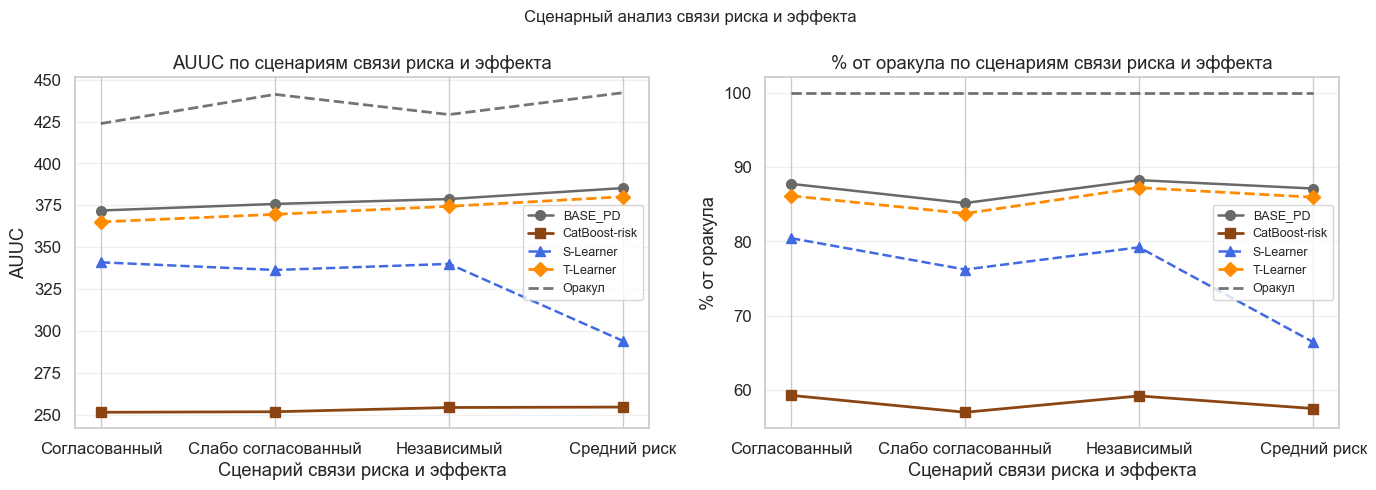


Ключевой вывод:
  Чем слабее связь риск → эффект, тем важнее моделирование индивидуального эффекта воздействия.
  В aligned сценарии риск-модели конкурентны структурно, а не содержательно.


In [80]:
# ====== График: AUUC по сценариям ======
_df_sw2 = pd.DataFrame(_sweep_rows)
_df_sw2 = _df_sw2[_df_sw2['Модель'] != 'Logged-policy oracle']

_sc_order = ['aligned', 'weakly_aligned', 'orthogonal', 'mid_risk']
_sc_labels = ['Согласованный', 'Слабо согласованный', 'Независимый', 'Средний риск']

_model_styles = {
    'BASE_PD':       ('dimgray',    'o-',  1.8),
    'CatBoost-risk': ('saddlebrown','s-',  2.0),
    'S-Learner':     ('royalblue',  '^--', 1.8),
    'T-Learner':     ('darkorange', 'D--', 2.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['AUUC', '% от оракула']):
    for mname, (color, marker, lw) in _model_styles.items():
        vals = []
        for sc in _sc_order:
            row = _df_sw2[(_df_sw2['Модель'] == mname) & (_df_sw2['Сценарий'] == sc)]
            vals.append(row[metric].values[0] if len(row) > 0 else float('nan'))
        ax.plot(_sc_labels, vals, marker[1:], marker=marker[0], color=color,
                linewidth=lw, label=mname, markersize=7)

    # Линия оракульного уровня
    oracle_vals = []
    for sc in _sc_order:
        row = pd.DataFrame(_sweep_rows)
        row = row[(row['Модель'] == 'Logged-policy oracle') & (row['Сценарий'] == sc)]
        oracle_vals.append(row[metric].values[0] if len(row) > 0 else float('nan'))
    ax.plot(_sc_labels, oracle_vals, 'k--', linewidth=2, label='Оракул', alpha=0.6)

    ax.set_xlabel('Сценарий связи риска и эффекта')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} по сценариям связи риска и эффекта')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сценарный анализ связи риска и эффекта',
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nКлючевой вывод:")
print("  Чем слабее связь риск → эффект, тем важнее моделирование индивидуального эффекта воздействия.")
print("  В aligned сценарии риск-модели конкурентны структурно, а не содержательно.")

<h3 id="uplift-scenario-interpretation">Интерпретация сценарного эксперимента</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Интерпретация сценарного эксперимента.</b>

<p><b>1. Сценарный анализ меняет постановку вопроса.</b></p>

После основного сравнения моделей можно было бы сделать простой вывод: T-Learner оказался лучшей обученной uplift-моделью. Но для практики этого недостаточно. Важно понять не только какая модель победила на конкретном датасете, но и при каких условиях uplift-подход действительно дает дополнительную ценность.

Сценарный эксперимент переводит анализ от вопроса <b>«какая модель лучше?»</b> к вопросу <b>«когда и почему эта модель полезна?»</b>.

<p><b>2. Risk-based стратегия может быть сильной по структурным причинам.</b></p>

Если базовый риск и эффект коммуникации согласованы, то риск-скоринг может выглядеть почти как uplift-модель. Это не означает, что risk-score оценивает причинный эффект. Он просто оказывается хорошим proxy, потому что механизм данных связывает рискованность клиента и потенциальную пользу контакта.

Именно поэтому в эксперименте отдельно рассматривается `BASE_PD`: это не production-модель, а синтетический идеализированный risk-ориентир. Он показывает, насколько сильной может быть risk-based логика, если риск и uplift структурно связаны.

<p><b>3. Uplift особенно нужен там, где риск и эффект расходятся.</b></p>

Главная практическая зона применения uplift — ситуации, где самый рискованный клиент не обязательно является самым изменяемым клиентом. Например, максимальный эффект может находиться в среднем risk-сегменте или зависеть от канала коммуникации. В таких условиях простая стратегия «контактировать top-risk» начинает терять управленческий смысл.

Uplift-модель полезна именно потому, что пытается ответить на другой вопрос: не <b>«кто рискованнее?»</b>, а <b>«чье поведение можно изменить коммуникацией?»</b>.

<p><b>4. Качество uplift зависит не только от алгоритма.</b></p>

Результаты сценариев показывают, что uplift-моделирование нельзя свести к выбору самого сложного causal-метода. На качество влияют:

<ul>
  <li>связь между риском и эффектом коммуникации;</li>
  <li>наличие overlap между contacted- и control-группами;</li>
  <li>баланс наблюдений по каналам;</li>
  <li>сила treatment effect относительно шума;</li>
  <li>историческая политика назначения контактов.</li>
</ul>

Поэтому диагностика данных является частью uplift-подхода, а не вспомогательным шагом.

<p><b>5. Методологический вклад эксперимента.</b></p>

Сценарный анализ показывает границы применимости выводов. Он не просто фиксирует, что T-Learner оказался сильным в одном запуске, а демонстрирует, при каких структурах данных risk-based стратегия может быть достаточной, а при каких требуется отдельная модель индивидуального эффекта.

<b>Итог.</b> Uplift следует внедрять не как замену кредитному скорингу, а как дополнительный слой принятия решений для коммуникаций: скоринг оценивает уровень риска, uplift-модель оценивает изменяемость этого риска под воздействием конкретного контакта.

</div>

<h2 id="uplift-conclusions">Итоговые выводы</h2>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Ноутбук показывает, что прогноз риска и оценка эффекта воздействия - разные задачи.

1. T-Learner и S-Learner устойчиво превосходят практические risk-based модели по AUUC.
2. Сильный результат `BASE_PD` показывает, что риск может имитировать uplift, если риск и эффект согласованы.
3. X-Learner и DR-Learner не дают преимущества в текущей постановке, что подчеркивает роль качества данных и overlap.
4. Bootstrap и проверка по `TRUE_UPLIFT` подтверждают, что результат T/S-Learner не является только случайной вариацией.
5. Сценарный анализ показывает границы применимости: uplift особенно нужен там, где изменяемый сегмент не совпадает с верхом риск-рейтинга.

Для текста работы этот ноутбук является экспериментальным ядром: он связывает модели, диагностику данных, оракулы, статистическую устойчивость и практические условия внедрения.

</div>
